# ATM Cash Demand Forecasting

### Multi-segment, hierarchical, machine-learning, and ensemble forecasting with ETNA

`Python` · `Time Series` · `ETNA` · `Prophet` · `CatBoost` · `Forecast Reconciliation`

## Project overview

This project develops a five-day forecasting workflow for ATM cash management. It models cash deposits, withdrawals, and net cash flow; evaluates data-quality treatments; compares statistical and machine-learning models; constructs a hierarchical representation; and tests recursive, direct, hybrid, and ensemble forecasting strategies.

> **Runtime requirement**
>
> ETNA 3 requires Python 3.10–3.12. In Google Colab, open **Runtime → Change runtime type** and select runtime version **2026.07** (Python 3.12). For local execution, use a Python 3.12 environment. The current package is installed as `ts-etna`, while imports continue to use `etna`.

In [89]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [7]:
%pip install --no-cache-dir "ts-etna[prophet]" catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 159.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 181.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 335.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 267.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 322.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 340.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 327.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 216.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.6/570.6 kB 239.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 255.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 249.1 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Foun

In [2]:
import warnings
import gdown
import pandas as pd
import numpy as np
import seaborn as sns
from copy import deepcopy

warnings.filterwarnings("ignore")

## Business context

ATM cash planning requires balancing two competing costs. Insufficient cash creates failed withdrawals and poor customer experience, while excess cash remains idle instead of generating a return elsewhere. Across a large ATM network, even modest forecasting improvements can materially reduce replenishment costs and improve capital efficiency.

The analysis uses daily transaction data from a real ATM in Turkey. Although the project focuses on one device, the workflow is designed around methods that can be extended to a larger network.

In [3]:
url = 'https://raw.githubusercontent.com/andrei-egorov/ml_se_seminars/master/atm_daily_cash.csv'
output = 'atm_daily_cash.csv'
gdown.download(url=url, output=output, quiet=False, fuzzy=True)

df = pd.read_csv('atm_daily_cash.csv')
df = df[4:] # Remove the initial incomplete rows before time-series processing

Downloading...
From: https://raw.githubusercontent.com/andrei-egorov/ml_se_seminars/master/atm_daily_cash.csv
To: /content/atm_daily_cash.csv
26.1kB [00:00, 24.6MB/s]                   


In [4]:
df.shape

(1182, 3)

## Dataset

The dataset contains daily cash deposits (`CashIn`) and withdrawals (`CashOut`). The initial rows are inspected before constructing the forecasting target and ETNA datasets.

In [5]:
df.head()

,Date,CashIn,CashOut
4,1/5/2016,20840.0,22200.0
5,1/6/2016,28460.0,18810.0
6,1/7/2016,19250.0,23210.0
7,1/8/2016,49770.0,4350.0
8,1/9/2016,NaN,NaN


### Net cash-flow target

Withdrawals are represented as negative values, and net cash flow is defined as:

$$target = CashIn + CashOut$$

This additive representation supports both direct forecasting of net demand and hierarchical reconciliation from its deposit and withdrawal components.

In [6]:
df['CashOut'] = -df['CashOut']
df['target'] = df['CashIn'] + df['CashOut']

## Exploratory data analysis

The initial analysis examines missingness, summary statistics, temporal behavior, weekday effects, pairwise relationships, and Pearson correlations. The objective is to identify trend, seasonality, anomalies, and dependencies that should influence preprocessing and feature engineering.

In [7]:
df['new_Date'] = pd.to_datetime(df['Date'])
df['WeekDay'] = df['new_Date']. dt.day_name ()
df.head()

,Date,CashIn,CashOut,target,new_Date,WeekDay
4,1/5/2016,20840.0,-22200.0,-1360.0,2016-01-05,Tuesday
5,1/6/2016,28460.0,-18810.0,9650.0,2016-01-06,Wednesday
6,1/7/2016,19250.0,-23210.0,-3960.0,2016-01-07,Thursday
7,1/8/2016,49770.0,-4350.0,45420.0,2016-01-08,Friday
8,1/9/2016,NaN,NaN,NaN,2016-01-09,Saturday


In [8]:
df.isna().sum(axis=0) # Missing values by column

,0
Date,0
CashIn,101
CashOut,88
target,110
new_Date,0
WeekDay,0


In [9]:
df.describe() # Descriptive statistics

,CashIn,CashOut,target,new_Date
count,1081.000000,1094.000000,1072.000000,1182
mean,37261.618871,-30985.648995,5976.651119,2017-08-17 12:00:00
min,100.000000,-111700.000000,-75190.000000,2016-01-05 00:00:00
25%,21690.000000,-40375.000000,-6277.500000,2016-10-26 06:00:00
50%,34980.000000,-27895.000000,5320.000000,2017-08-17 12:00:00
75%,50280.000000,-18010.000000,18515.000000,2018-06-08 18:00:00
max,121300.000000,-0.000000,85160.000000,2019-03-31 00:00:00
std,20583.186636,18314.048275,21551.659802,NaN


### Temporal patterns and correlations

The monthly view suggests that transaction volumes generally increase over the sample, while the weekly series exposes substantial short-term volatility and recurring calendar structure. Because withdrawals are stored as negative values, the **−0.39** correlation between `CashIn` and `CashOut` indicates that larger deposits tend to coincide with larger withdrawal magnitudes. Net cash flow is positively related to both signed components (`CashIn`: **0.62**, `CashOut`: **0.49**), confirming that neither stream alone explains the ATM's net position.

<Axes: xlabel='new_Date'>

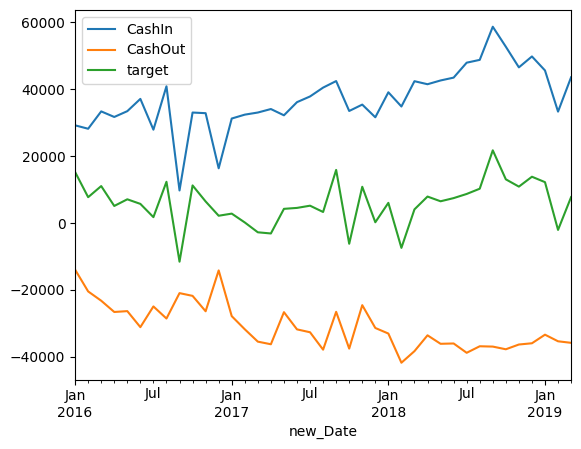

In [10]:
df[['CashIn', 'CashOut', 'target', 'new_Date']].resample('M', on='new_Date').mean().plot() # Monthly aggregation

<Axes: xlabel='new_Date'>

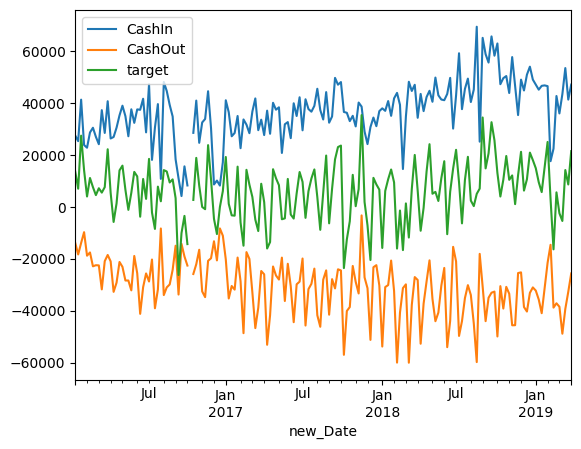

In [11]:
df[['CashIn', 'CashOut', 'target', 'new_Date']].resample('W', on='new_Date').mean().plot() # Weekly aggregation reveals recurring structure

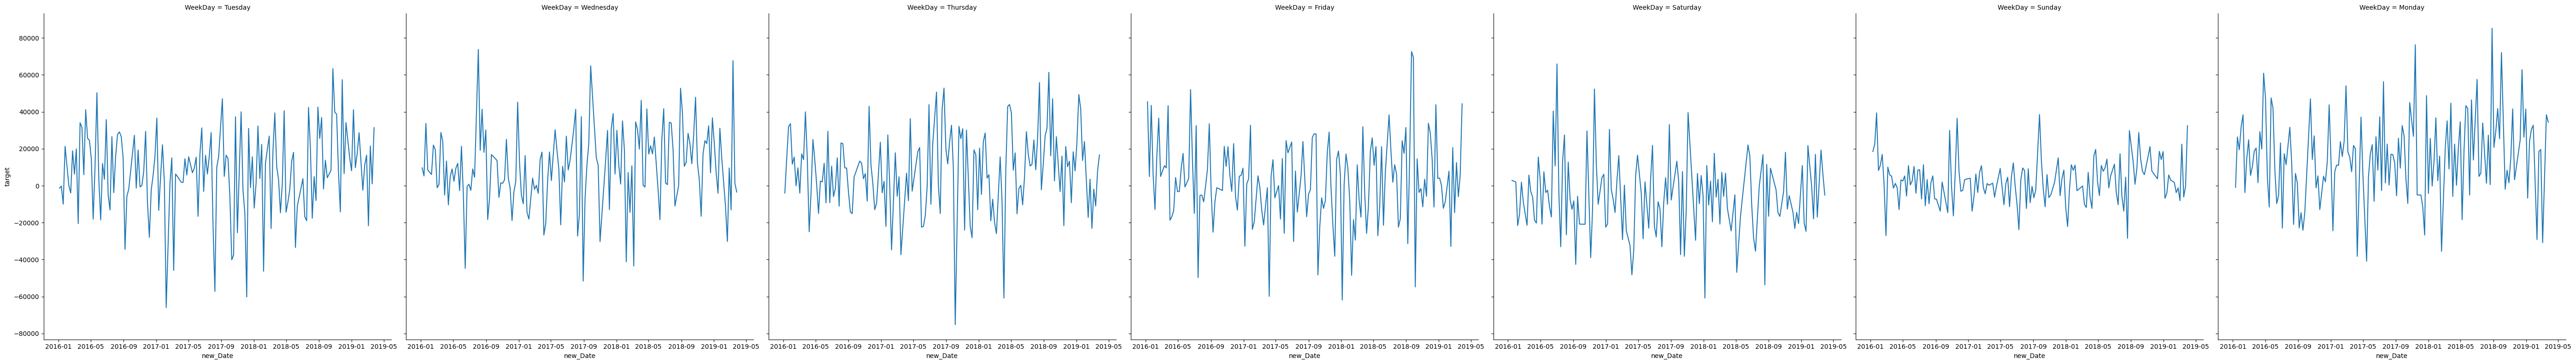

In [12]:
g = sns.FacetGrid(df, col="WeekDay", height=8, aspect=1.0) # Compare weekday-specific seasonal patterns
g.map(sns.lineplot, 'new_Date',  "target")

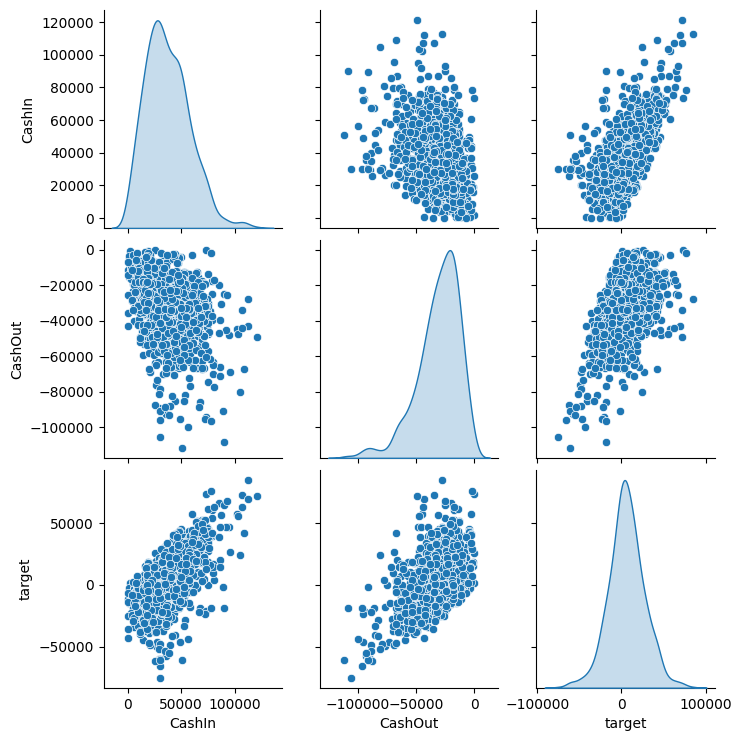

In [13]:
sns.pairplot(df, diag_kind="kde");

<Axes: >

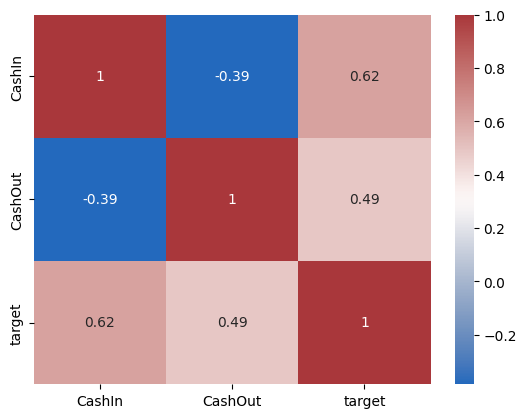

In [14]:
cmap = sns.color_palette("vlag", as_cmap=True)
sns.heatmap(df[['CashIn', 'CashOut', 'target']].corr("pearson"), annot=True, cmap=cmap)

## Multi-segment time-series representation

The three related series are reshaped from wide to long format with `pd.melt`, converted into ETNA's internal dataset structure, and wrapped in a daily `TSDataset`. The original dataframe is retained for later hierarchical analysis.

In [15]:
from etna.datasets import TSDataset

In [16]:
new_df = df.copy(deep=True)
new_df.head()

,Date,CashIn,CashOut,target,new_Date,WeekDay
4,1/5/2016,20840.0,-22200.0,-1360.0,2016-01-05,Tuesday
5,1/6/2016,28460.0,-18810.0,9650.0,2016-01-06,Wednesday
6,1/7/2016,19250.0,-23210.0,-3960.0,2016-01-07,Thursday
7,1/8/2016,49770.0,-4350.0,45420.0,2016-01-08,Friday
8,1/9/2016,NaN,NaN,NaN,2016-01-09,Saturday


In [17]:
new_df["timestamp"] = pd.to_datetime(new_df["Date"])
new_df["target"] = new_df["target"]
new_df.drop(columns=["Date", "new_Date","WeekDay"], inplace=True)
new_df.head()

,CashIn,CashOut,target,timestamp
4,20840.0,-22200.0,-1360.0,2016-01-05
5,28460.0,-18810.0,9650.0,2016-01-06
6,19250.0,-23210.0,-3960.0,2016-01-07
7,49770.0,-4350.0,45420.0,2016-01-08
8,NaN,NaN,NaN,2016-01-09


In [21]:
new_df = pd.melt(
    new_df,id_vars=["timestamp"],
    value_vars=["CashIn", "CashOut","target"],
    var_name="segment",
    value_name="value",
    ).rename(columns={"value": "target"})
new_df.head()

,timestamp,segment,target
0,2016-01-05,CashIn,20840.0
1,2016-01-06,CashIn,28460.0
2,2016-01-07,CashIn,19250.0
3,2016-01-08,CashIn,49770.0
4,2016-01-09,CashIn,NaN


In [23]:
new_df = TSDataset.to_dataset(new_df)
ts = TSDataset(new_df, freq="D")
ts.info()

<class 'etna.datasets.TSDataset'>
num_segments: 3
num_exogs: 0
num_regressors: 0
num_known_future: 0
freq: D
end_timestamp: 2019-03-31 00:00:00
         start_timestamp  length  num_missing
segments                                     
CashIn        2016-01-05    1182          101
CashOut       2016-01-05    1182           88
target        2016-01-05    1182          110


## Data quality: missing values and anomalies

Cash transaction data contain irregular gaps and extreme observations. Several ETNA imputation strategies are compared visually, and a cleaned copy is maintained so raw and preprocessed pipelines can be evaluated independently.

In [24]:
import etna

In [27]:
from etna.analysis import (cross_corr_plot, distribution_plot, plot_anomalies,
                           plot_anomalies_interactive, plot_backtest,
                           plot_imputation,
                           plot_correlation_matrix, plot_forecast,
                           acf_plot)
from etna.analysis.outliers import (get_anomalies_density, get_anomalies_hist,
                                    get_anomalies_median,
                                    get_anomalies_prediction_interval)
from etna.datasets import TSDataset
from etna.ensembles import DirectEnsemble, StackingEnsemble, VotingEnsemble
from etna.metrics import MAE, MAPE, MSE, SMAPE
from etna.models import (
    CatBoostPerSegmentModel,
    CatBoostMultiSegmentModel,
    LinearPerSegmentModel,
    MovingAverageModel,
    NaiveModel,
    ProphetModel,
    SeasonalMovingAverageModel,
)
from etna.pipeline import AutoRegressivePipeline, Pipeline, assemble_pipelines
from etna.transforms import (DateFlagsTransform, FilterFeaturesTransform,
                             HolidayTransform, LagTransform,
                             LinearTrendTransform, LogTransform, MeanTransform,
                             MedianOutliersTransform, DensityOutliersTransform, SegmentEncoderTransform,
                             TimeSeriesImputerTransform)

In [28]:
ts.describe()

,start_timestamp,end_timestamp,length,num_missing,num_segments,num_exogs,num_regressors,num_known_future,freq
segments,,,,,,,,,
CashIn,2016-01-05,2019-03-31,1182,101,3,0,0,0,D
CashOut,2016-01-05,2019-03-31,1182,88,3,0,0,0,D
target,2016-01-05,2019-03-31,1182,110,3,0,0,0,D


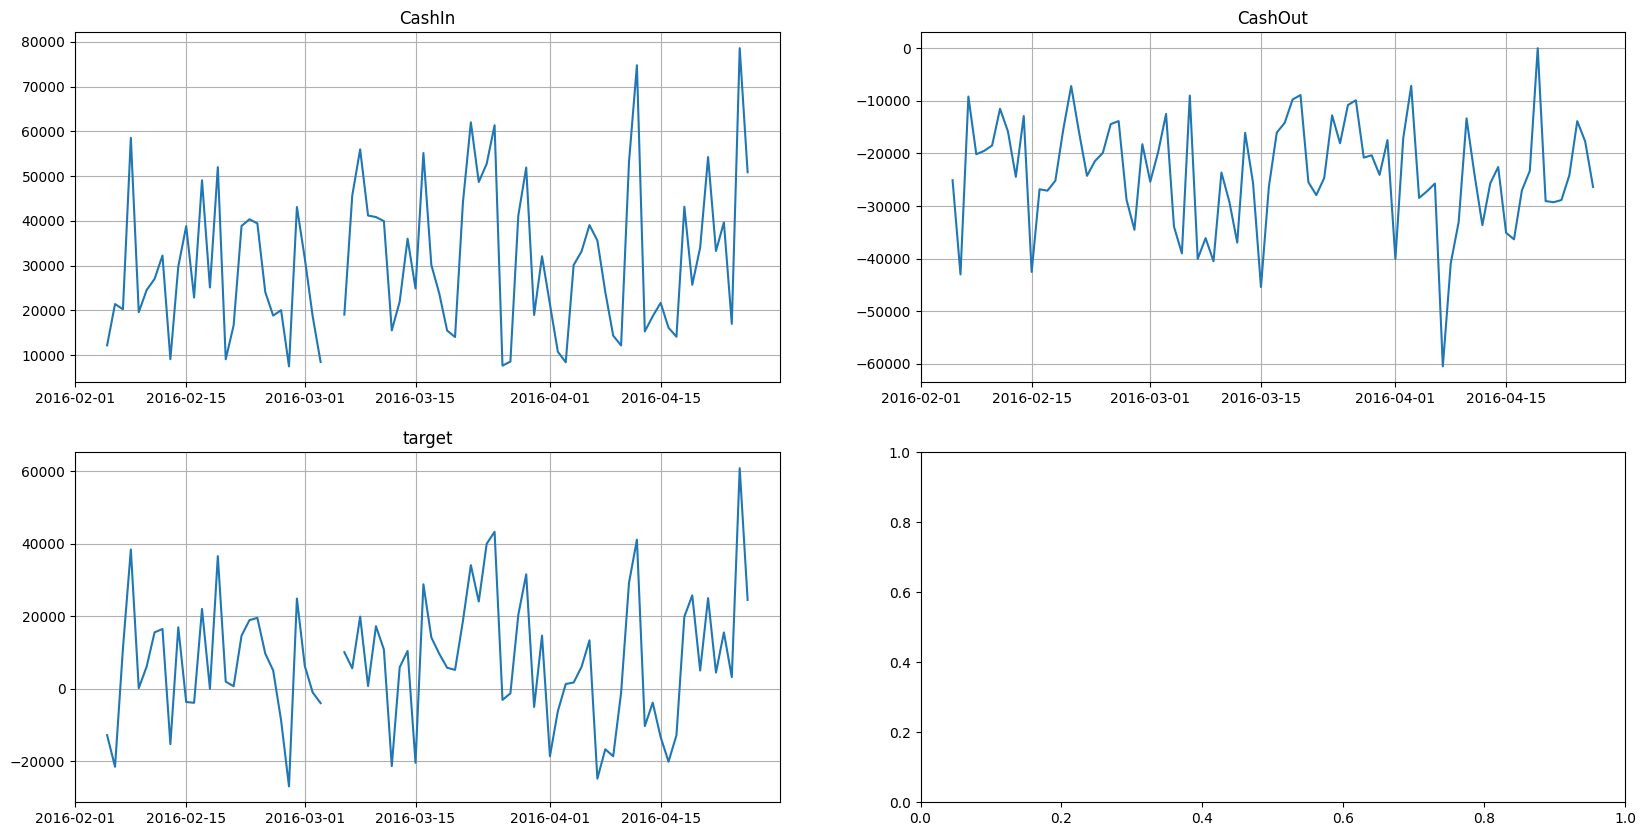

In [29]:
ts.plot(
    segments=("CashIn",
              "CashOut",
              "target"
             ),
    start="2016-02-05", end="2016-04-26" # Inspect the weekly seasonal pattern
)

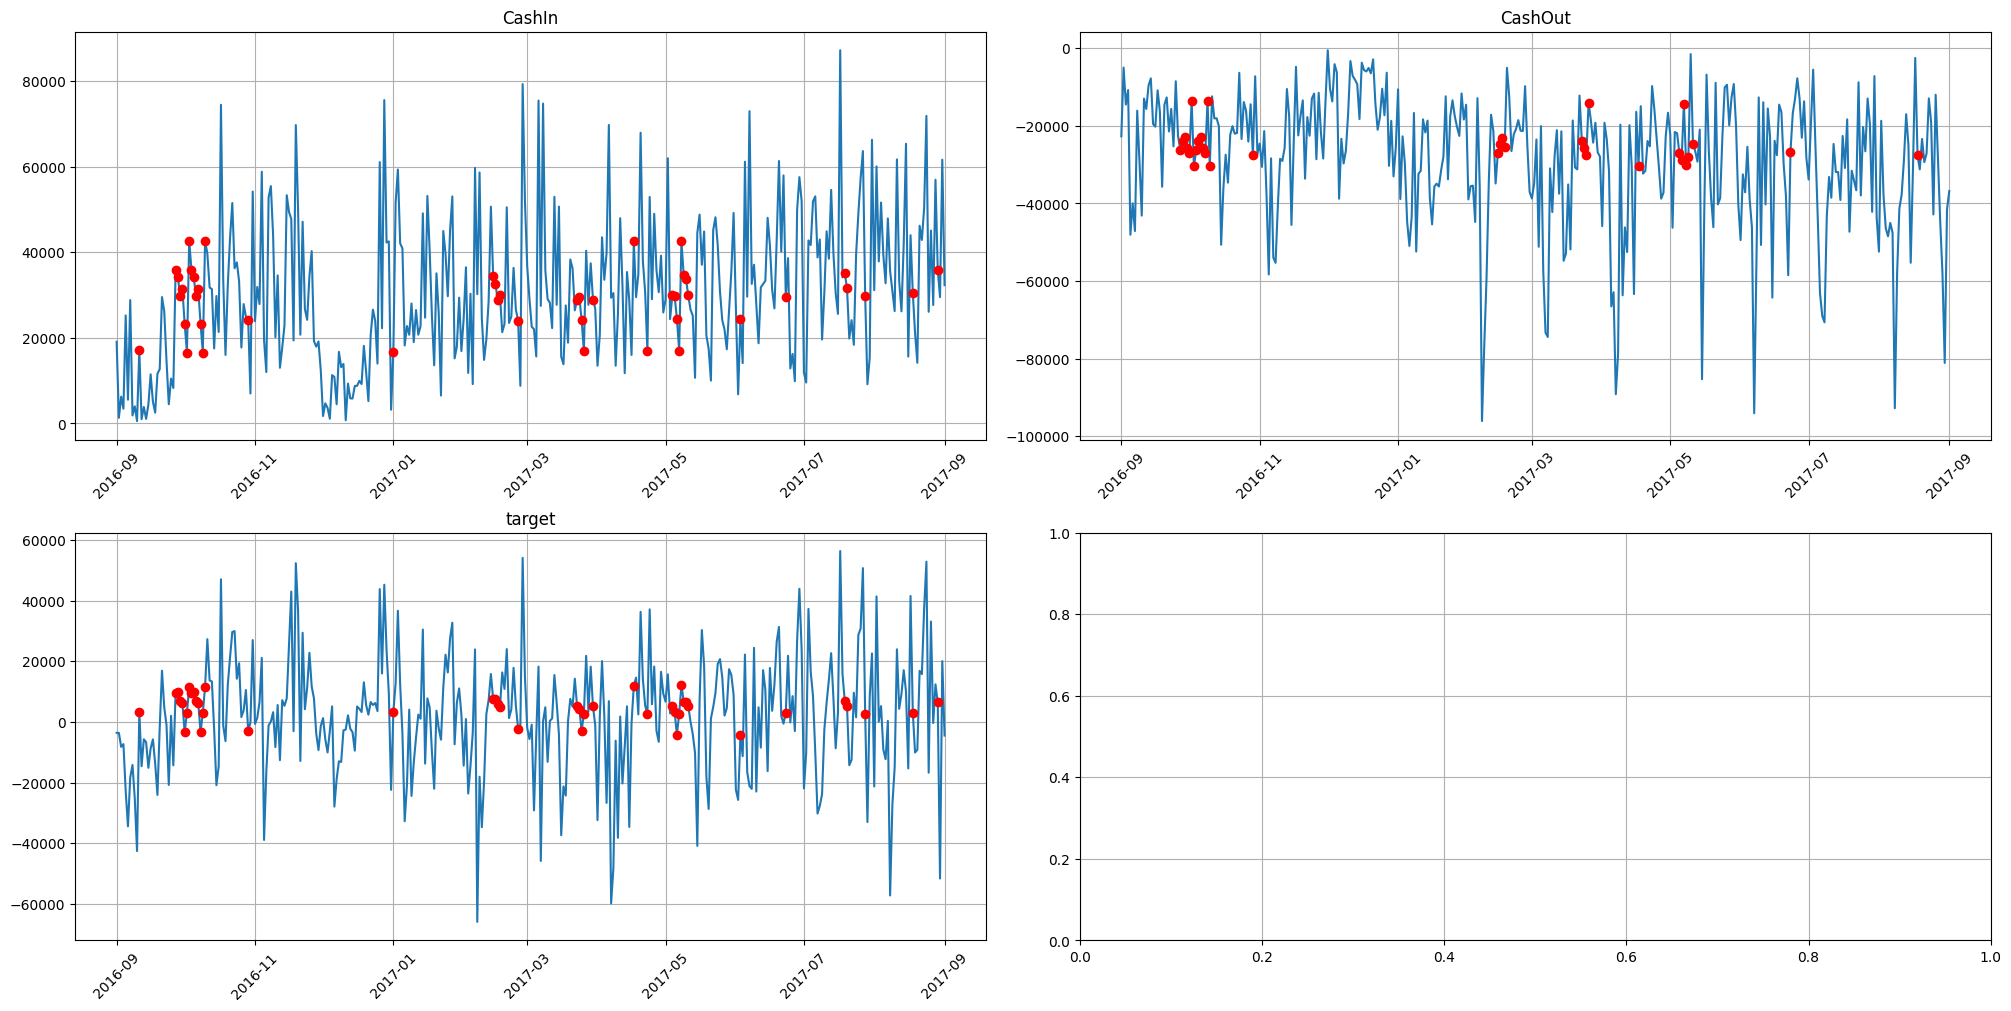

In [30]:
imputer = TimeSeriesImputerTransform(in_column='target', strategy="seasonal", seasonality = 7)
plot_imputation(ts, imputer, start='2016-09-01', end='2017-09-01')

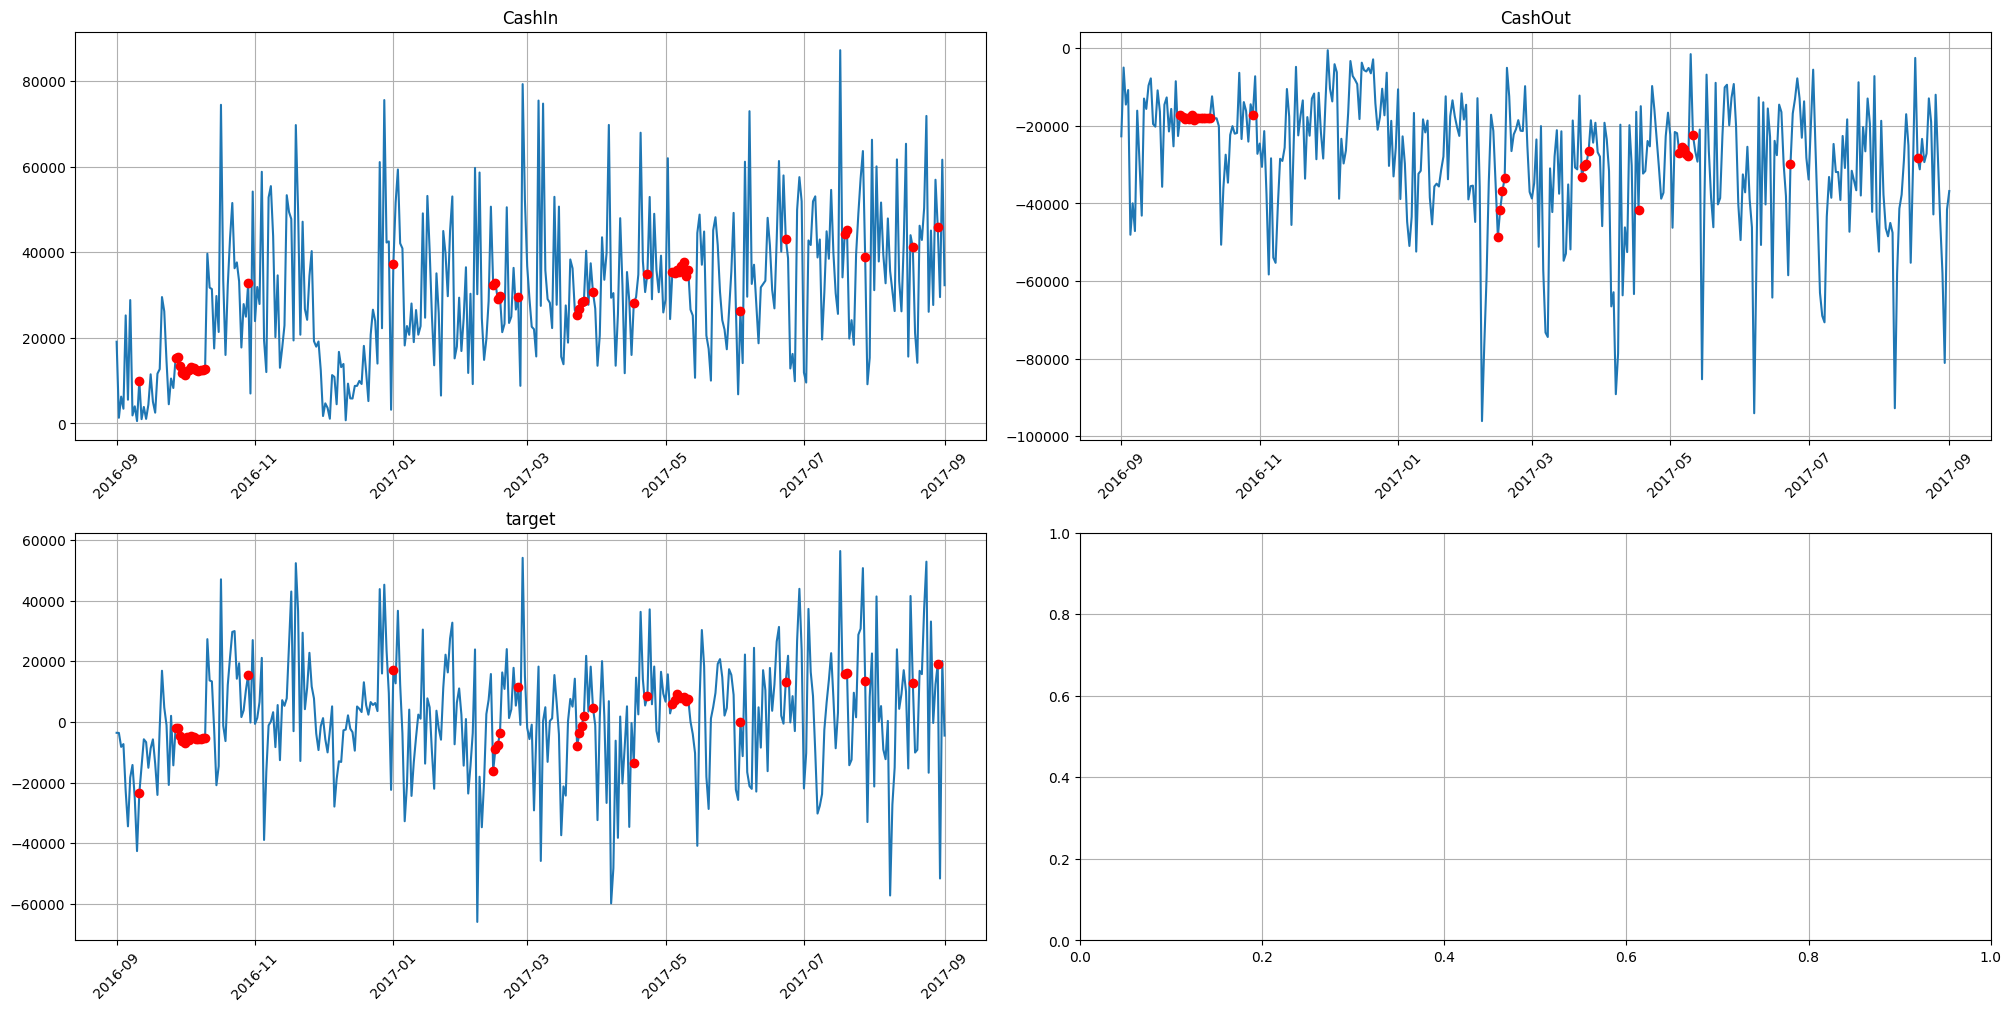

In [31]:
imputer = TimeSeriesImputerTransform(in_column='target', strategy="running_mean", window=7)
plot_imputation(ts, imputer, start='2016-09-01', end='2017-09-01')

### Imputation decision

The visual comparison favors seven-day seasonal imputation over the seven-observation running mean because it better preserves the recurring weekly pattern across longer gaps. A mean-imputation fallback fills the initial observations for which a complete seasonal history is unavailable. The final dataset check confirms that this two-stage procedure removes all missing values in the three segments.

In [32]:
new_ts = deepcopy(ts)
new_ts.fit_transform([TimeSeriesImputerTransform(in_column="target", strategy="seasonal", seasonality = 7)])


In [33]:
new_new_ts = deepcopy(new_ts) # Fill the early value that lacks a complete seven-day seasonal history
new_new_ts.fit_transform([TimeSeriesImputerTransform(in_column="target", strategy="mean")])

In [34]:
new_new_ts.info()

<class 'etna.datasets.TSDataset'>
num_segments: 3
num_exogs: 0
num_regressors: 0
num_known_future: 0
freq: D
end_timestamp: 2019-03-31 00:00:00
         start_timestamp  length  num_missing
segments                                     
CashIn        2016-01-05    1182            0
CashOut       2016-01-05    1182            0
target        2016-01-05    1182            0


### Anomaly detection

Multiple anomaly detectors are evaluated to distinguish unusual transactions from recurrent weekly behavior. Candidate detections are inspected visually before selecting the cleaning transform used in downstream pipelines.

In [35]:
segment = "target"
method = get_anomalies_median
params_bounds = {"window_size": (10, 70, 5), "alpha": (0.1, 4, 0.25)}

The median-based detector is explored with a 45-day window and sensitivity parameter $\alpha=2.35$. This provides a robust local reference that is less sensitive to isolated extreme values.

In [36]:
plot_anomalies_interactive(
    ts=new_new_ts, segment=segment, method=method, params_bounds=params_bounds
)

interactive(children=(IntSlider(value=10, continuous_update=False, description='window_size', max=70, min=10, …

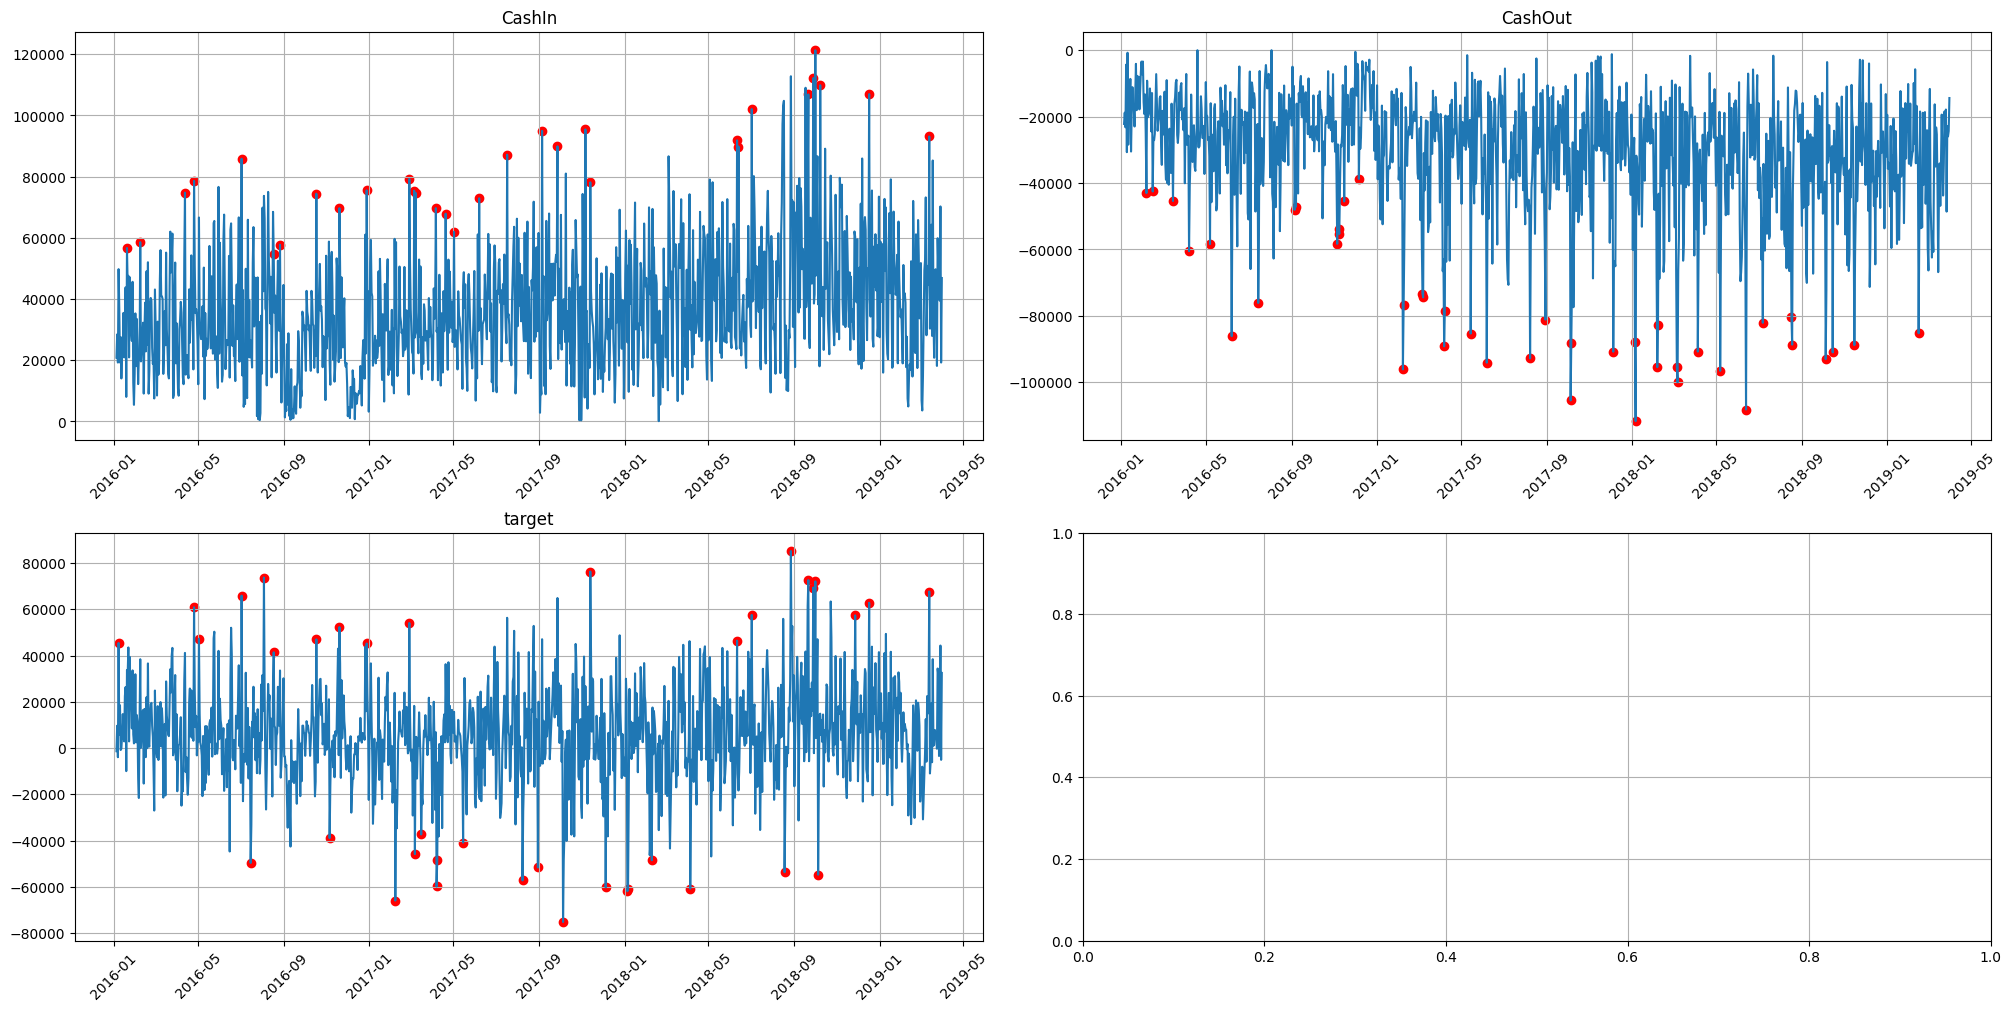

In [37]:
anomalies = get_anomalies_median(new_new_ts, window_size=45, alpha = 2.35)
plot_anomalies(new_new_ts, anomalies)

The density-based detector provides a practical balance with `window_size=30`, `distance_coef=1.5`, and `n_neighbors=7`. These parameters are retained for the production-style preprocessing pipeline.

In [38]:
segment = "target"
method = get_anomalies_density
params_bounds = {"window_size": (10, 70, 5), "distance_coef": (0.5, 4, 0.25), "n_neighbors":(1, 10, 1)}
plot_anomalies_interactive(
    ts=new_new_ts,segment=segment, method=method, params_bounds=params_bounds
)

interactive(children=(IntSlider(value=10, continuous_update=False, description='window_size', max=70, min=10, …

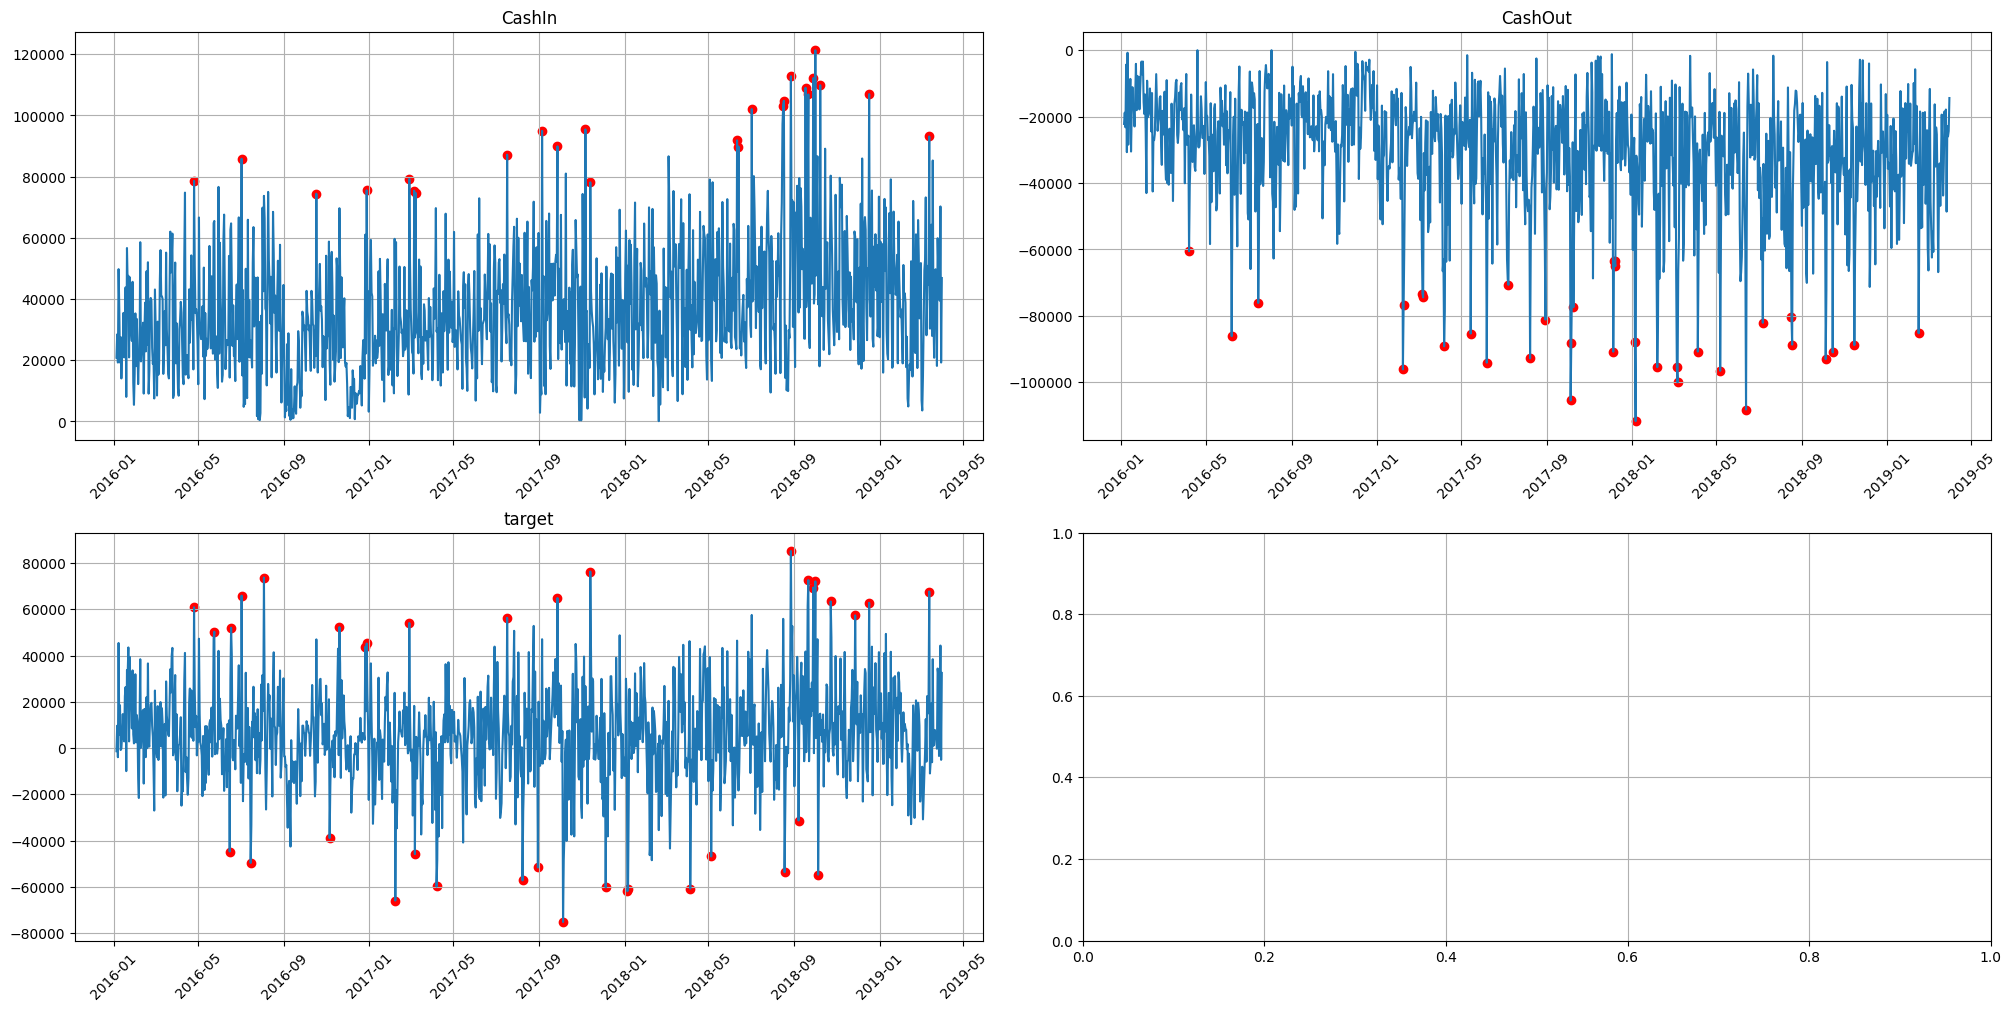

In [39]:
anomalies = get_anomalies_density(new_new_ts, window_size=30, distance_coef = 1.5, n_neighbors = 7)
plot_anomalies(new_new_ts, anomalies)

A Prophet prediction-interval detector is inspected as a model-based alternative to the local median and density rules. The density-based method is retained for downstream experiments because it provides a transparent, locally adaptive definition of unusual transactions and can be applied consistently inside each forecasting pipeline.

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


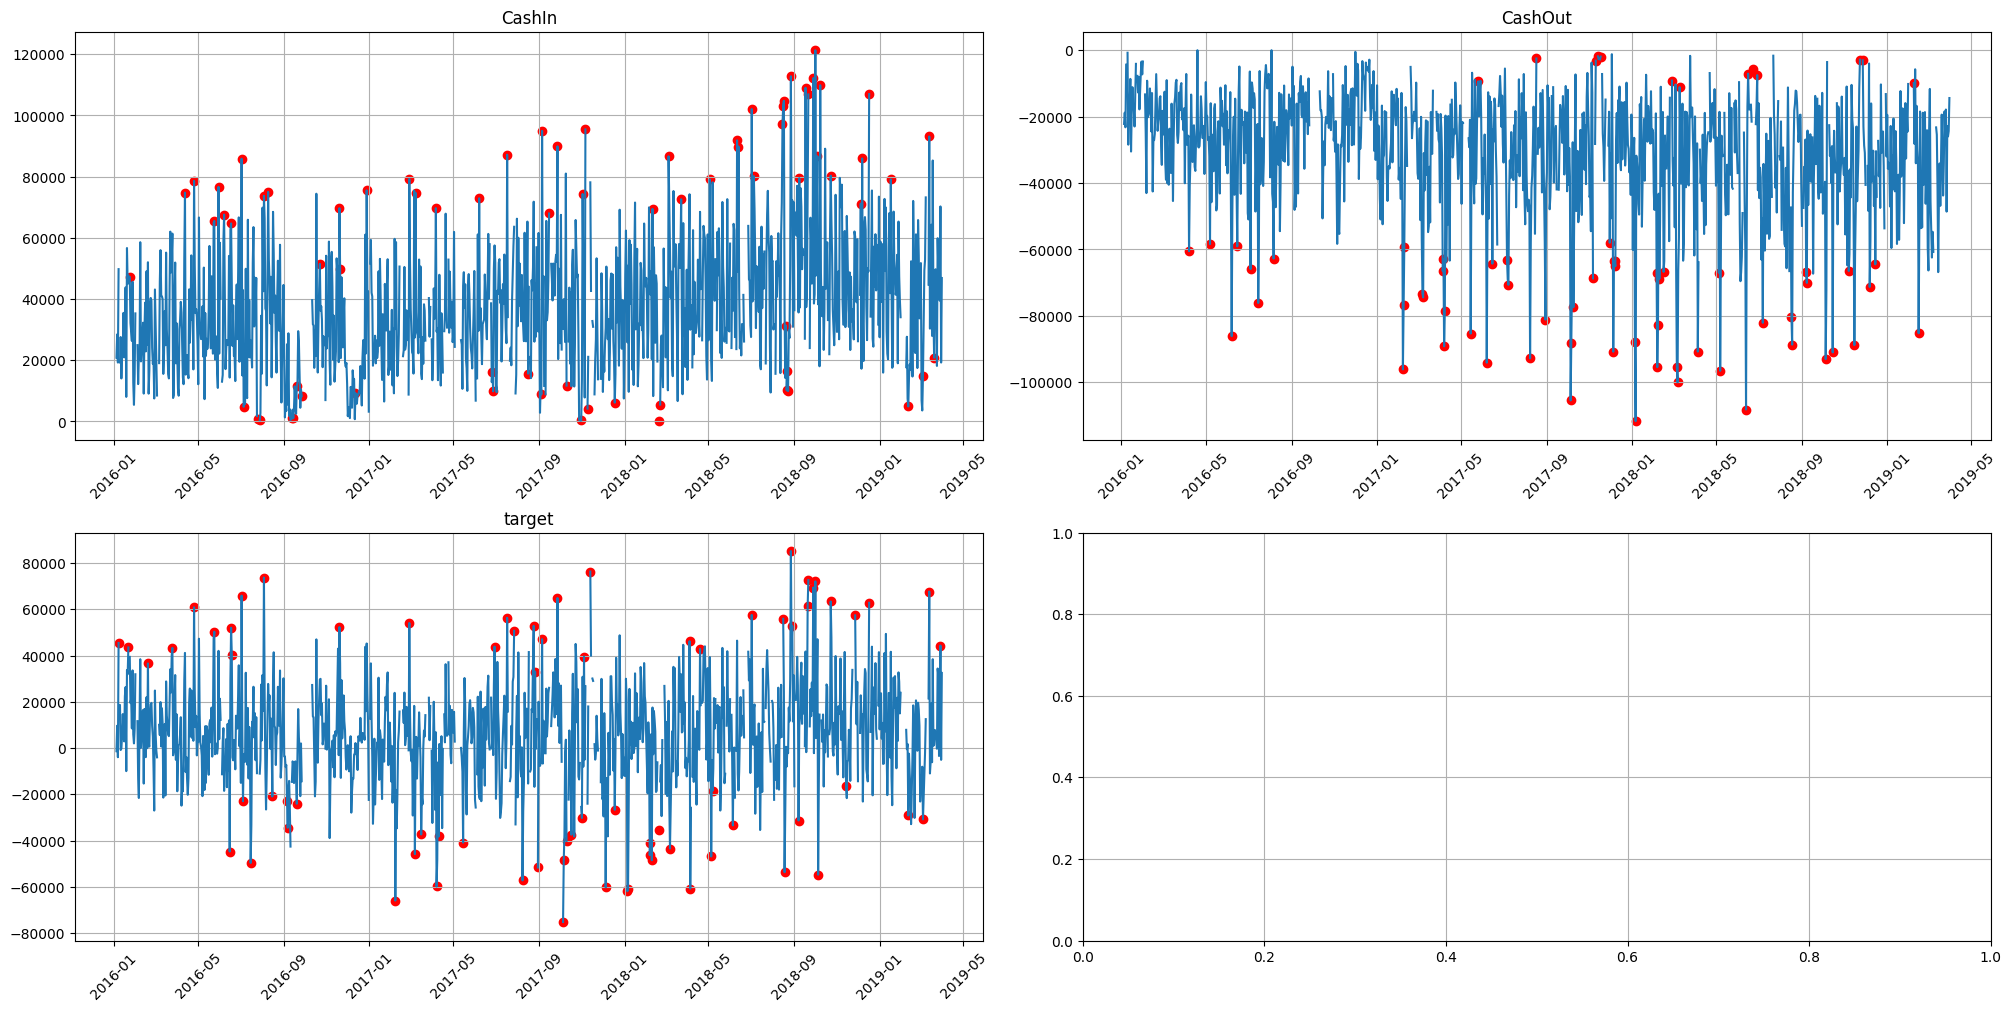

In [40]:
anomaly_dict = get_anomalies_prediction_interval(
    new_new_ts, model=ProphetModel, interval_width=0.95
)

plot_anomalies(ts, anomaly_dict)

In [41]:
outliers_remover = DensityOutliersTransform(in_column="target", window_size=30, n_neighbors=7, distance_coef=1.5)
# Impute NaNs using the specified strategy
new1_ts = deepcopy(new_new_ts)
outliers_imputer = TimeSeriesImputerTransform(
    in_column="target", strategy="seasonal", seasonality = 7
)
new1_ts.fit_transform([outliers_remover, outliers_imputer])

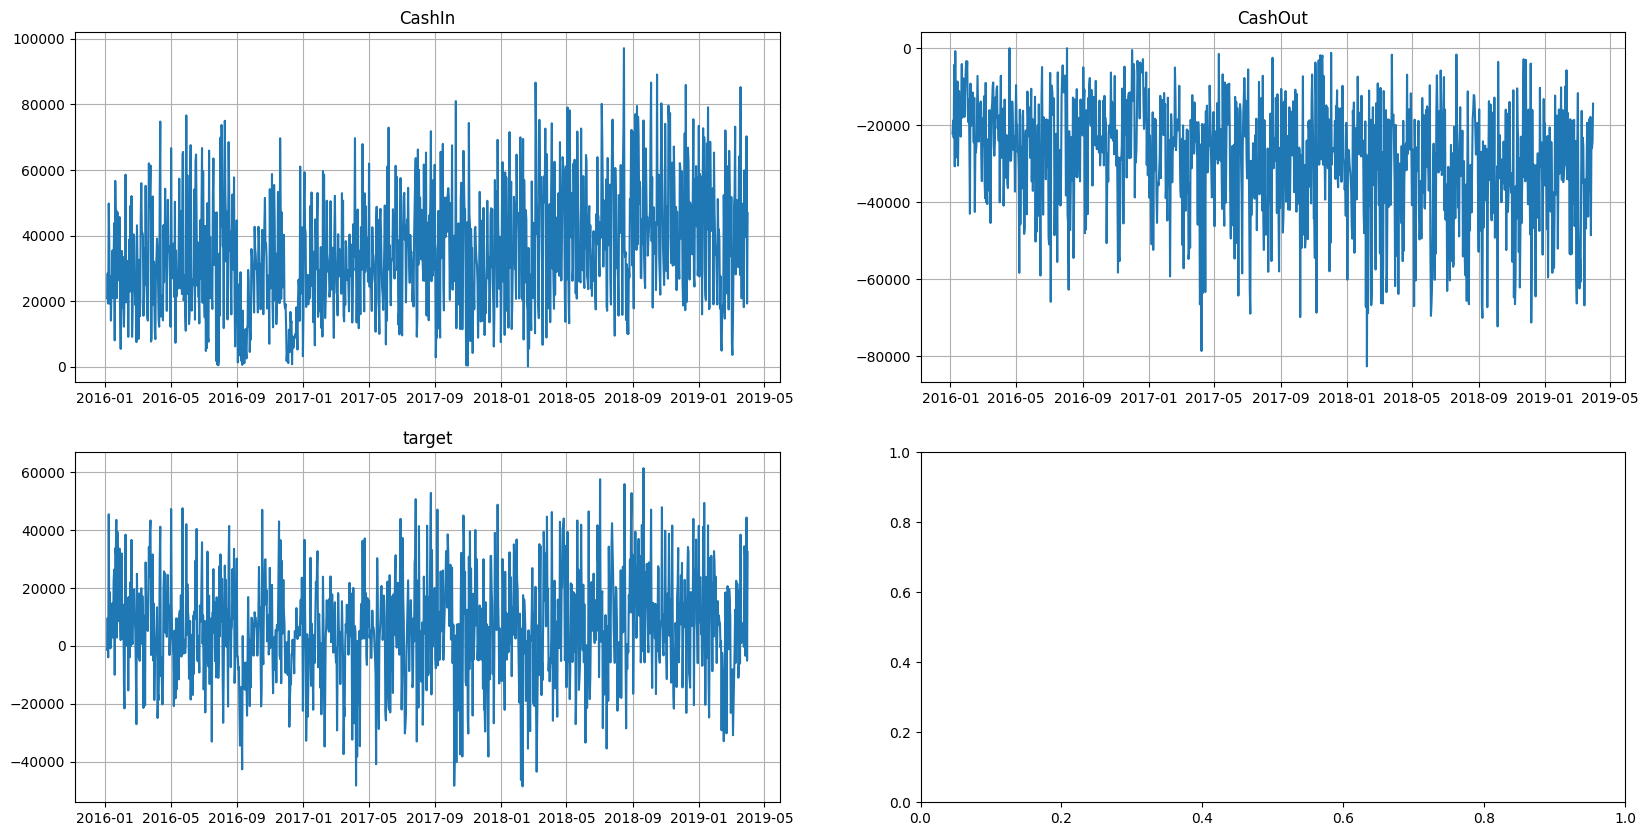

In [42]:
new1_ts.plot()

## Prophet benchmark

A multi-segment Prophet pipeline establishes the statistical forecasting benchmark. Performance is estimated with three-fold backtesting over a five-day horizon using both SMAPE and MAE. Raw and anomaly-cleaned pipelines are evaluated side by side, and their forecasts are visualized against historical data.

In [43]:
from etna.pipeline import Pipeline
from etna.models import ProphetModel
from etna.metrics import SMAPE, MAE
from etna.analysis import plot_backtest

In [44]:
HORIZON = 5

In [49]:
pipeline = Pipeline(
    model=ProphetModel(),
    transforms=[],
    horizon=HORIZON,
)

pipeline_outliers = Pipeline(
    model=ProphetModel(),
    transforms=[
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="mean",
        ),
        DensityOutliersTransform(
            in_column="target",
            window_size=30,
            n_neighbors=7,
            distance_coef=1.5,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
    ],
    horizon=HORIZON,
)

# Backtest the baseline Prophet pipeline
backtest_result = pipeline.backtest(
    ts=ts,
    metrics=[SMAPE(), MAE()],
    n_folds=3,
    aggregate_metrics=True,
)

metrics = backtest_result["metrics"]
forecast = backtest_result["forecasts"]
fold_info = backtest_result["fold_info"]

# Backtest the Prophet pipeline with outlier processing
backtest_outliers_result = pipeline_outliers.backtest(
    ts=ts,
    metrics=[SMAPE(), MAE()],
    n_folds=3,
    aggregate_metrics=True,
)

metrics_outliers = backtest_outliers_result["metrics"]
forecast_outliers = backtest_outliers_result["forecasts"]
fold_info_outliers = backtest_outliers_result["fold_info"]

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.5s
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    1.1s
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=T

In [50]:
print(metrics)

   segment       SMAPE           MAE
0   CashIn   32.926756  13647.477000
1  CashOut   39.973229  12842.017090
2   target  122.243675  14257.113803


In [51]:
print(metrics_outliers)

   segment       SMAPE           MAE
0   CashIn   30.647620  12573.042227
1  CashOut   36.760578  11374.009253
2   target  122.293494  13964.717889


### Comparing component and net forecasts

Per-segment metrics help determine whether net cash flow should be forecast directly or reconstructed from separate `CashIn` and `CashOut` predictions. MAE is especially informative for the net series because percentage errors become unstable when the target approaches or crosses zero.

Preprocessing reduces Prophet MAE for all three series and improves SMAPE for both transaction components. Net-flow SMAPE remains essentially unchanged—and is intrinsically unstable because the target frequently approaches or crosses zero—so MAE is treated as the primary selection metric. The stronger component-level results continue to motivate hierarchical and component-aware forecasting experiments.

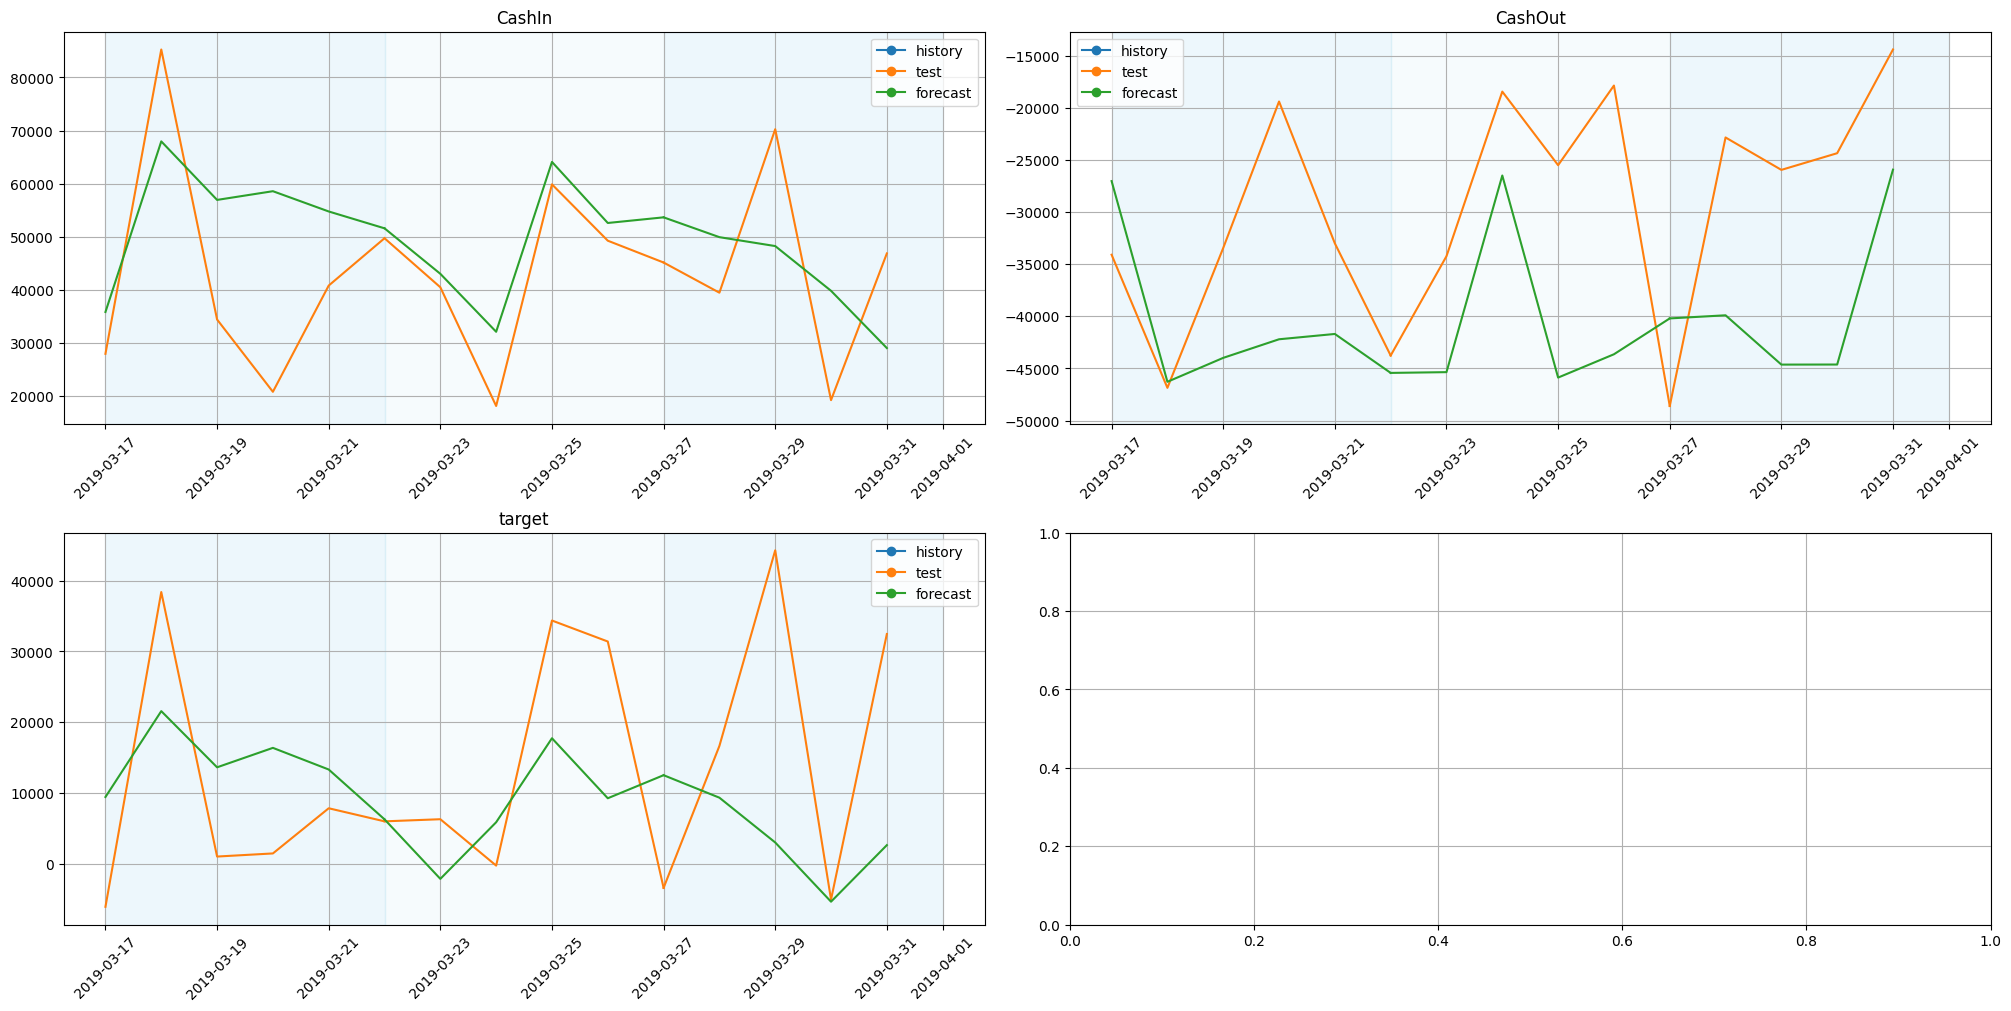

In [52]:
plot_backtest(forecast, ts)

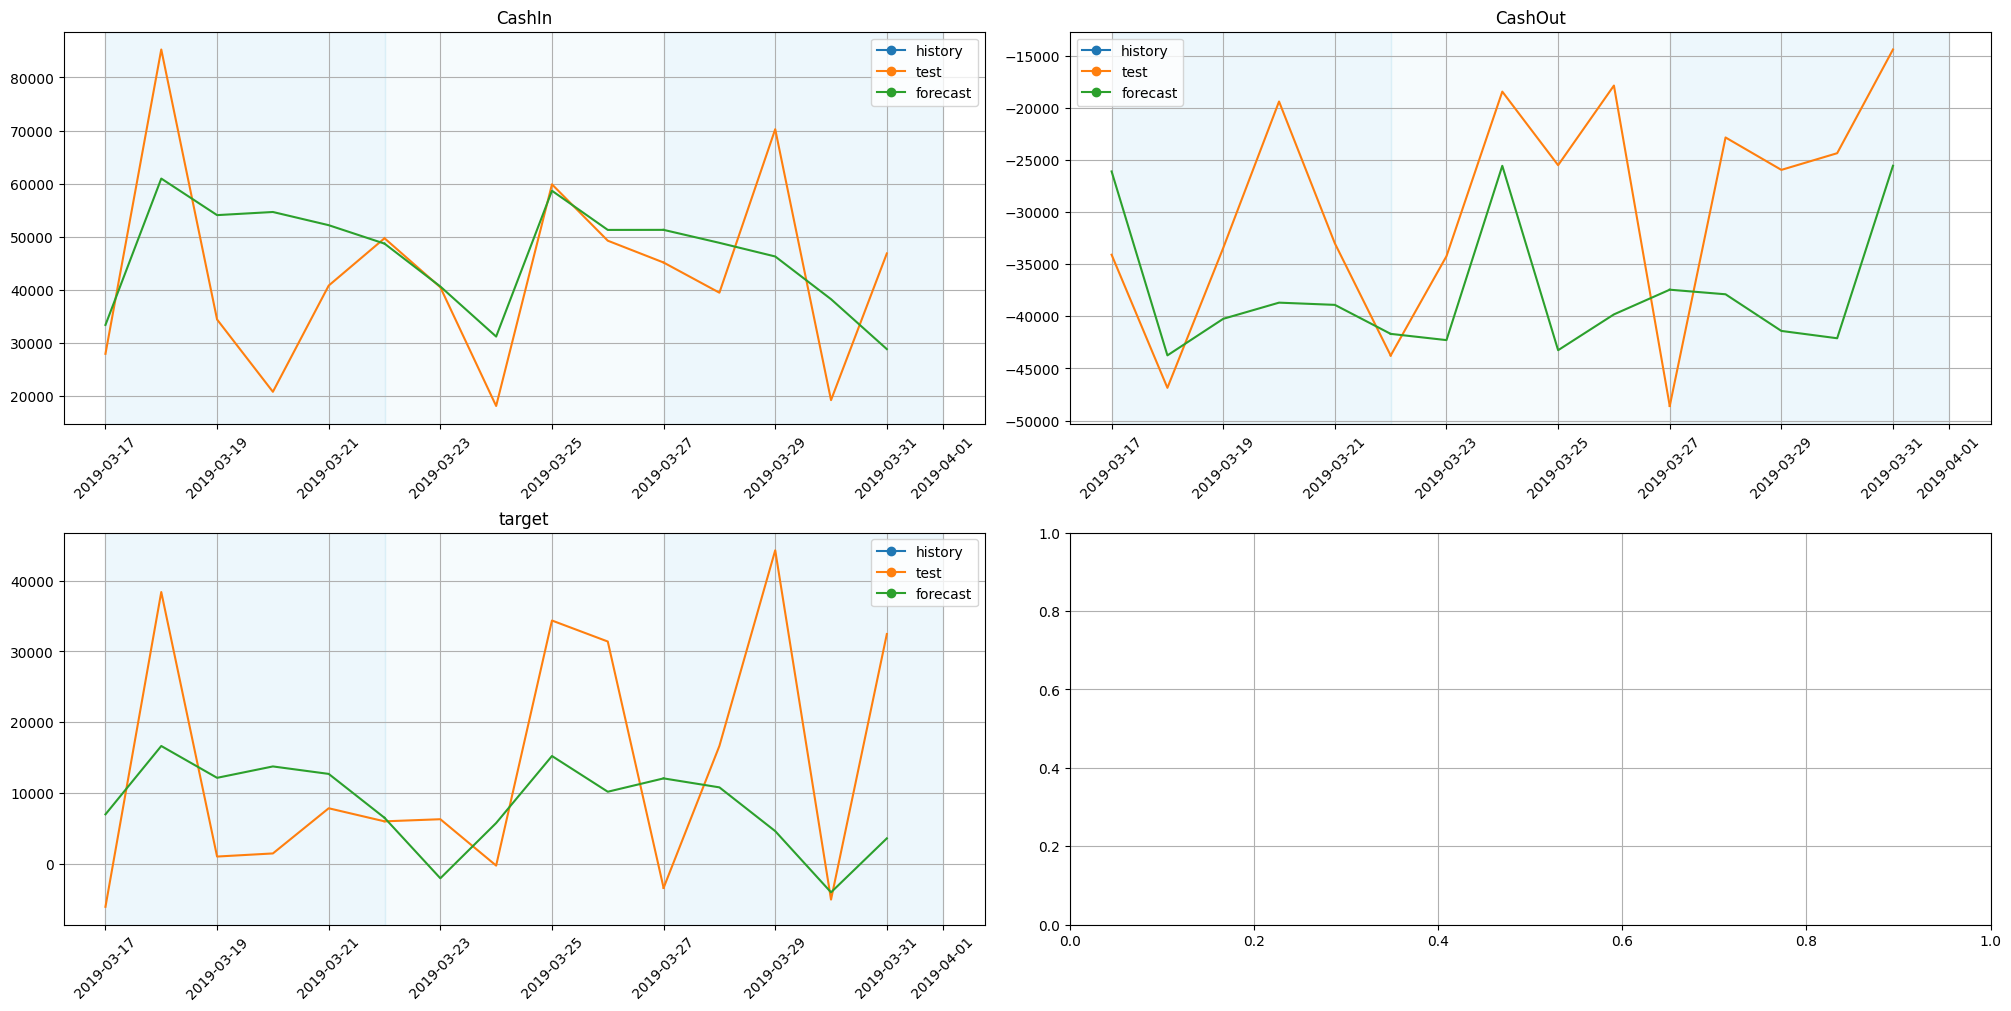

In [53]:
plot_backtest(forecast_outliers, ts)

## Hierarchical forecasting and reconciliation

Net cash flow has a natural additive hierarchy: `CashIn` and `CashOut` form the bottom level, while their sum forms the total level. The component series are converted into a hierarchical `TSDataset`, and a bottom-up reconciliator is fitted to guarantee coherent aggregate forecasts.

This design follows ETNA's hierarchical forecasting workflow and mirrors operational systems in which individual transaction streams must agree with an overall cash position.

In [54]:
from etna.datasets import HierarchicalStructure
from etna.pipeline import HierarchicalPipeline
from etna.reconciliation import BottomUpReconciliator

In [55]:
data = df.copy(deep=True)

periods = len(data)
data["timestamp"] = pd.date_range("2016-01-05", periods=periods, freq="D")
data.set_index("timestamp", inplace=True)

data = data[['target', 'CashIn', 'CashOut']]
data.head()

,target,CashIn,CashOut
timestamp,,,
2016-01-05,-1360.0,20840.0,-22200.0
2016-01-06,9650.0,28460.0,-18810.0
2016-01-07,-3960.0,19250.0,-23210.0
2016-01-08,45420.0,49770.0,-4350.0
2016-01-09,NaN,NaN,NaN


In [56]:
reason_segments = ["CashIn", "CashOut"]
data[reason_segments].head()

,CashIn,CashOut
timestamp,,
2016-01-05,20840.0,-22200.0
2016-01-06,28460.0,-18810.0
2016-01-07,19250.0,-23210.0
2016-01-08,49770.0,-4350.0
2016-01-09,NaN,NaN


In [57]:
hierarchical_data = []
for segment_name in reason_segments:
    segment = data[segment_name]

    segment_slice = pd.DataFrame(
        {"timestamp": segment.index, "target": segment.values, "segment": [segment_name] * periods}
    )
    hierarchical_data.append(segment_slice)

hierarchical_df = pd.concat(hierarchical_data, axis=0)

hierarchical_df.head()

,timestamp,target,segment
0,2016-01-05,20840.0,CashIn
1,2016-01-06,28460.0,CashIn
2,2016-01-07,19250.0,CashIn
3,2016-01-08,49770.0,CashIn
4,2016-01-09,NaN,CashIn


In [58]:
hierarchical_df = TSDataset.to_dataset(df=hierarchical_df)

In [59]:
hierarchical_structure = HierarchicalStructure(
    level_structure={"total": ["CashIn", "CashOut"]}, level_names=["total", "reason"]
)

hierarchical_ts = TSDataset(df=hierarchical_df, freq="D", hierarchical_structure=hierarchical_structure)

hierarchical_ts.head()

segment,CashIn,CashOut
feature,target,target
timestamp,,
2016-01-05,20840.0,-22200.0
2016-01-06,28460.0,-18810.0
2016-01-07,19250.0,-23210.0
2016-01-08,49770.0,-4350.0
2016-01-09,NaN,NaN


In [60]:
hierarchical_ts.current_df_level

'reason'

In [61]:
reconciliator = BottomUpReconciliator(target_level="total", source_level="reason")
reconciliator.fit(ts=hierarchical_ts)
reconciliator.mapping_matrix.toarray()

reconciliator.aggregate(ts=hierarchical_ts).head()




segment,CashIn,CashOut
feature,target,target
timestamp,,
2016-01-05,20840.0,-22200.0
2016-01-06,28460.0,-18810.0
2016-01-07,19250.0,-23210.0
2016-01-08,49770.0,-4350.0
2016-01-09,NaN,NaN


The selected seasonal imputation and density-based anomaly treatment are applied within a hierarchical Prophet pipeline. Three-fold backtesting evaluates the reconciled total forecast using MAE.

In [63]:
pipeline = HierarchicalPipeline(
    model=ProphetModel(),
    transforms=[
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="mean",
        ),
        DensityOutliersTransform(
            in_column="target",
            window_size=30,
            n_neighbors=7,
            distance_coef=1.5,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
    ],
    horizon=HORIZON,
    reconciliator=BottomUpReconciliator(
        target_level="total",
        source_level="reason",
    ),
)

bottom_up_result = pipeline.backtest(
    ts=hierarchical_ts,
    metrics=[MAE()],
    n_folds=3,
    aggregate_metrics=True,
)

bottom_up_metrics = bottom_up_result["metrics"]
bottom_up_forecast = bottom_up_result["forecasts"]
bottom_up_fold_info = bottom_up_result["fold_info"]

bottom_up_metrics = (
    bottom_up_metrics
    .set_index("segment")
    .add_suffix("_bottom_up")
)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.5s
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    1.0s
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    1.7s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.7s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.7s
[Parallel(n_jobs=1)]: Don

In [64]:
print(bottom_up_metrics)

         MAE_bottom_up
segment               
total     14273.468092


## Feature engineering for machine-learning models

The project returns to the multi-segment representation to build predictive features for linear and CatBoost models. Autocorrelation and partial-autocorrelation plots show meaningful short-lag and weekly dependence, while the periodogram highlights approximately monthly, weekly, and half-weekly cycles. The candidate feature set therefore incorporates:

- strategy-specific lag windows anchored in recent and weekly history;
- linear trend estimates;
- weekday, month, and week-position indicators;
- Friday and weekend flags relevant to the Turkish operating context;
- beginning- and mid-month salary-cycle indicators;
- holiday information where applicable;
- STL-derived components for CatBoost.

Together, these features represent weekly behavior, pay-cycle effects, calendar structure, and local trend.

In [68]:
from etna.analysis import acf_plot, stl_plot
from etna.ensembles import DirectEnsemble, StackingEnsemble, VotingEnsemble
from etna.models import (CatBoostPerSegmentModel,
                        CatBoostMultiSegmentModel,
                         AutoARIMAModel)
from etna.transforms import STLTransform, LagTransform, SegmentEncoderTransform
from etna.transforms import DateFlagsTransform, FilterFeaturesTransform, HolidayTransform

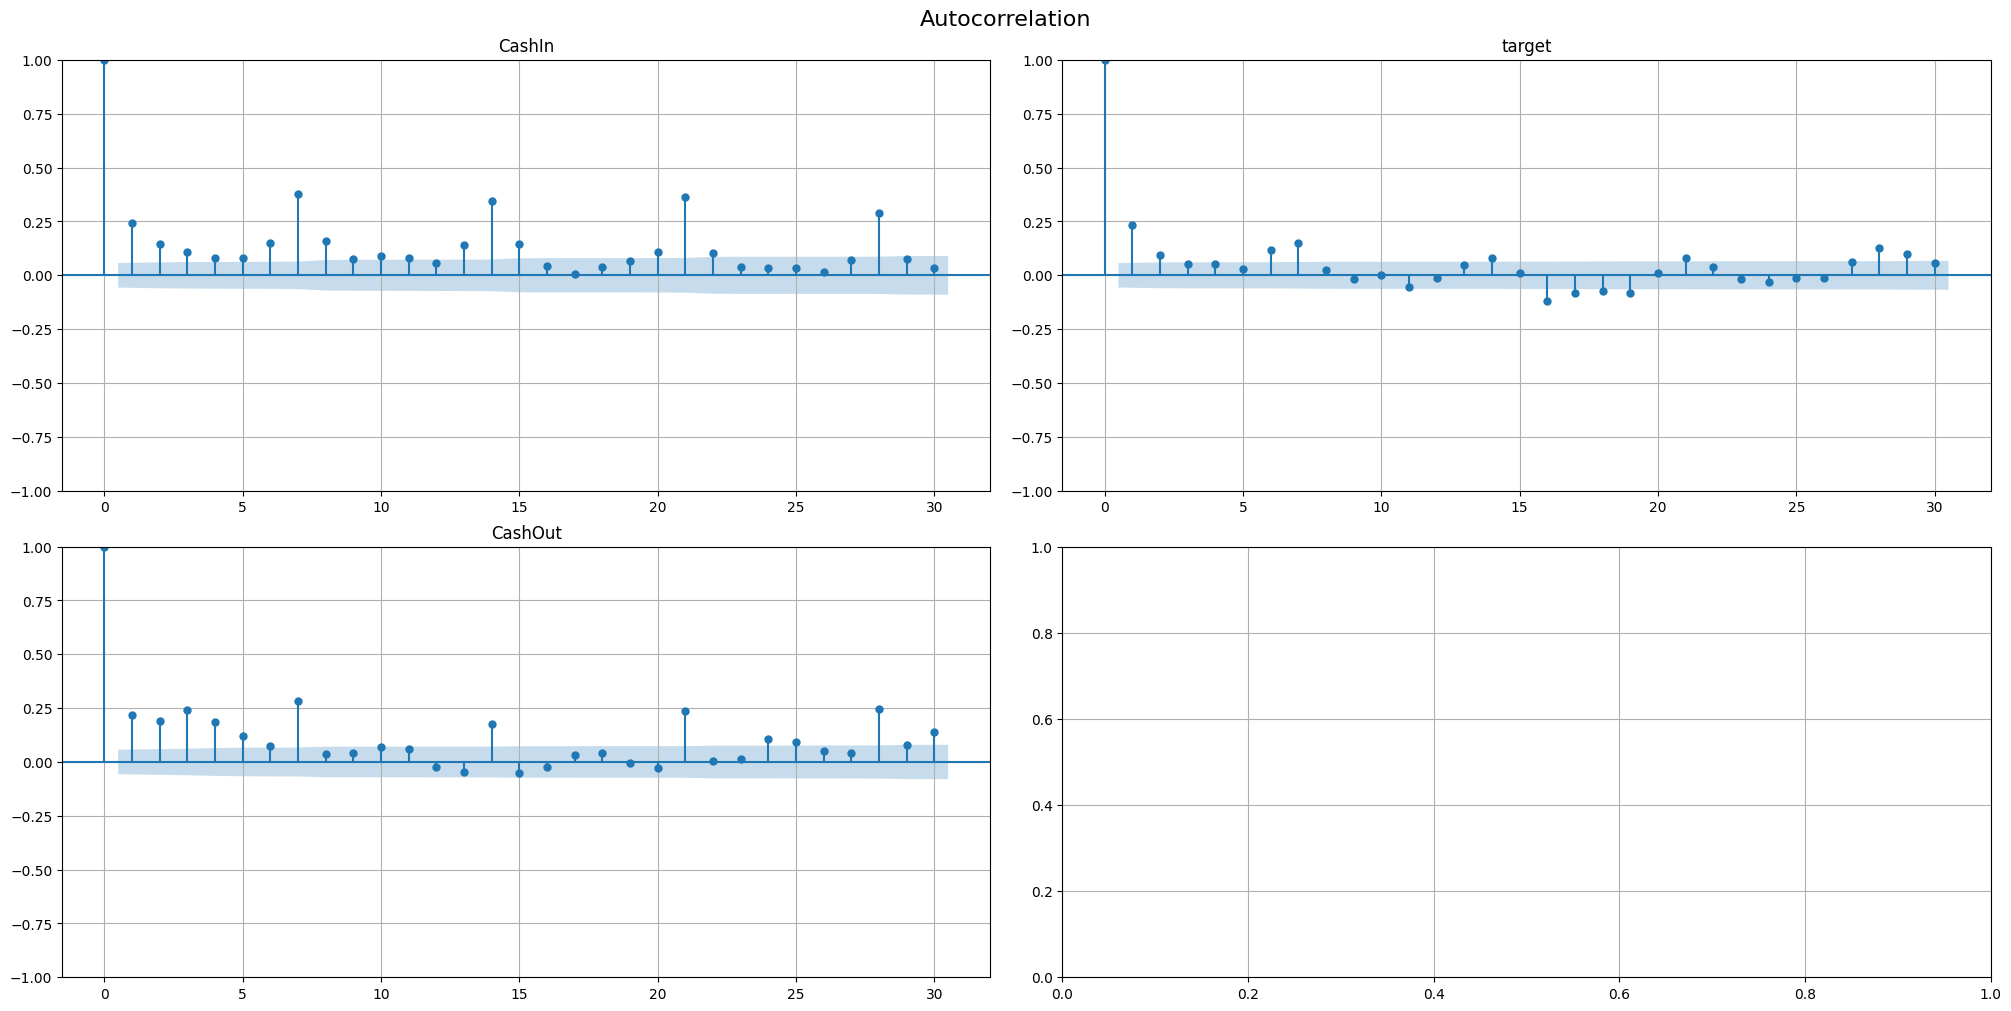

In [69]:
acf_plot(new1_ts, lags=30)

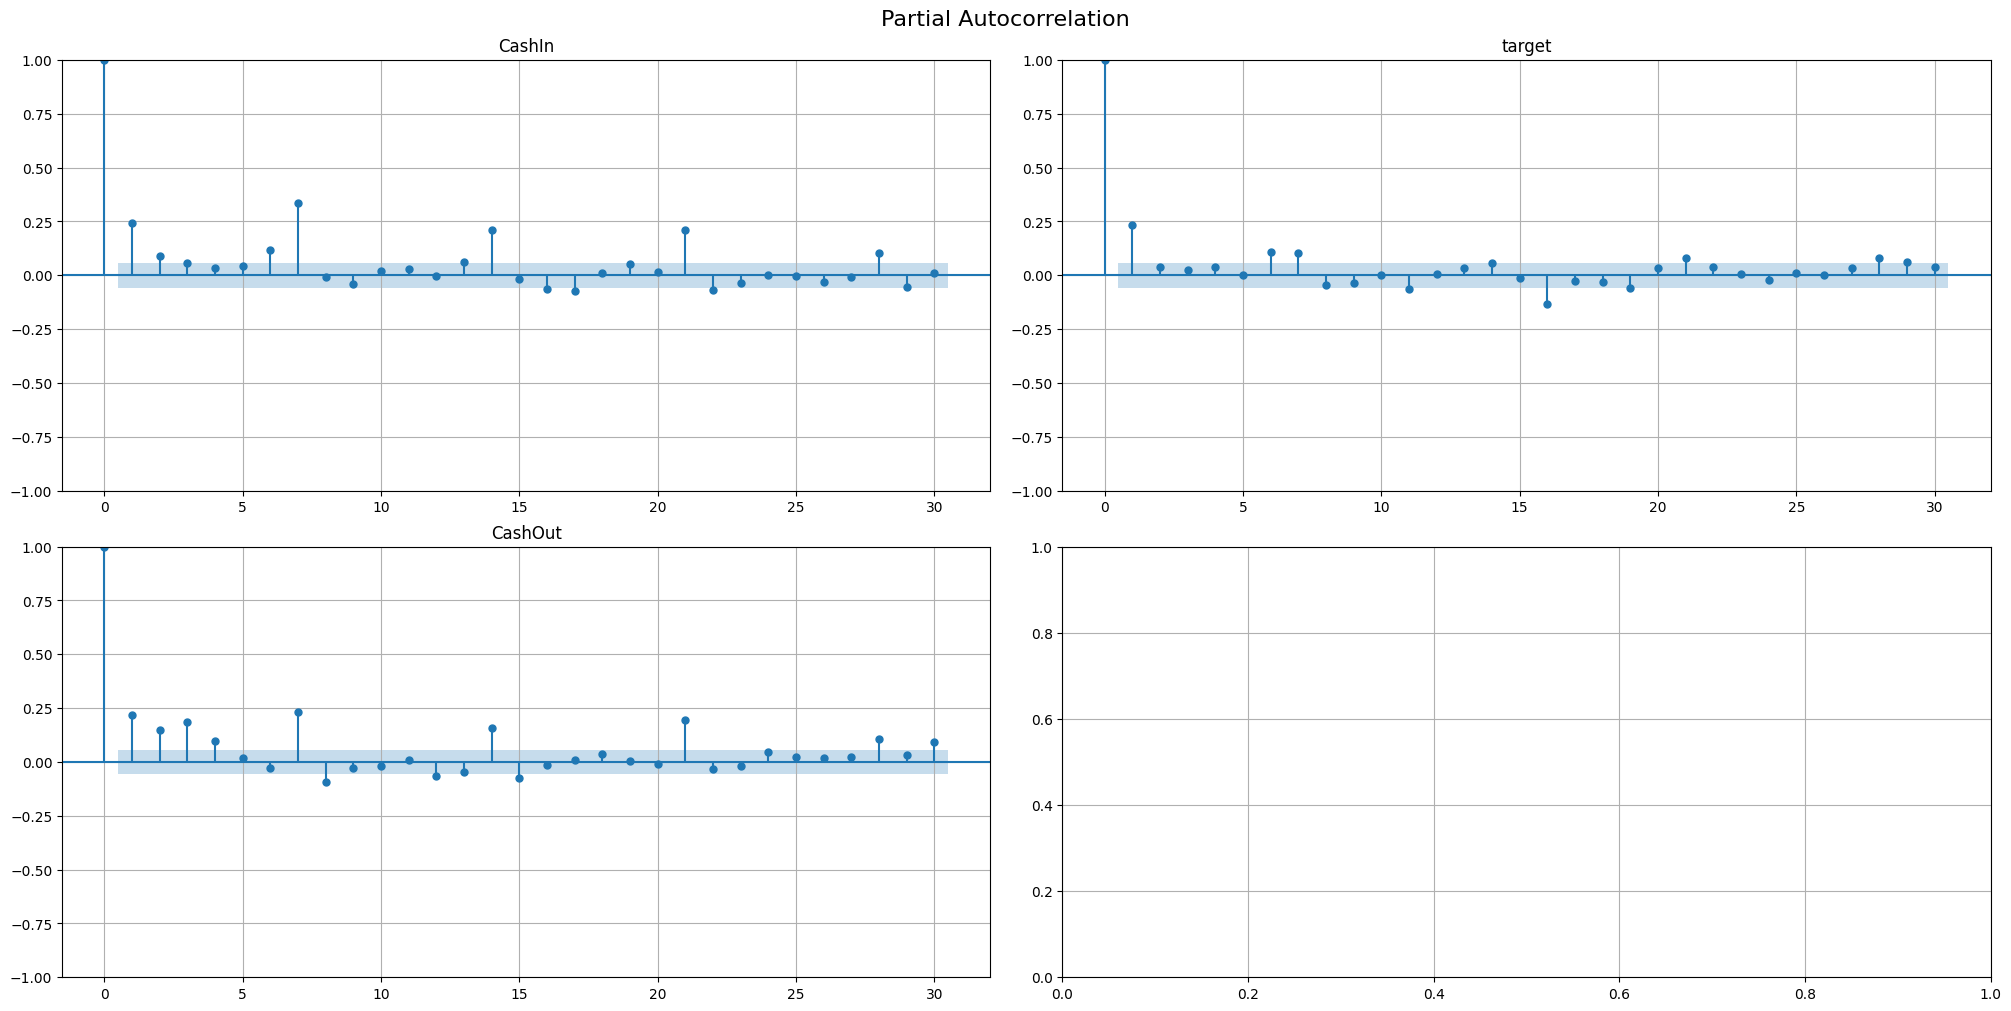

In [71]:
acf_plot(new1_ts, lags=30, partial=True)

In [72]:
d_flags = DateFlagsTransform(
    day_number_in_week=True,
    day_number_in_month=True,
    week_number_in_month=True,
    week_number_in_year=True,
    month_number_in_year=True,
    year_number=False,
    special_days_in_week=[4, 5, 6], # Friday and weekend behavior may affect transactions in Turkey
    special_days_in_month = [1, 15] # Approximate twice-monthly salary-cycle effects
)

### Linear per-segment model

The per-segment linear model provides a transparent feature-based diagnostic. Because this particular `Pipeline` uses ETNA's default one-step horizon, its metrics are not included in the later five-day model ranking; the explicitly configured autoregressive version provides the comparable multi-step linear result.

In [74]:
pipeline = Pipeline(
    transforms=[
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="mean",
        ),
        DensityOutliersTransform(
            in_column="target",
            window_size=30,
            n_neighbors=7,
            distance_coef=1.5,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
        LinearTrendTransform(in_column="target"),
        LagTransform(in_column="target", lags=[7]),
        d_flags,
        HolidayTransform(
            iso_code="TUR",
            out_column="TUR_holidays",
        ),
    ],
    model=LinearPerSegmentModel(),
)

backtest_result = pipeline.backtest(
    ts=ts,
    metrics=[SMAPE(), MAE()],
    n_folds=3,
    aggregate_metrics=True,
)

metrics = backtest_result["metrics"]
forecast = backtest_result["forecasts"]
fold_info = backtest_result["fold_info"]

metrics

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    1.5s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.5s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    1.6s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    1.6s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s finished


,segment,SMAPE,MAE
0,CashIn,47.941670,19011.189300
1,CashOut,31.585303,7622.724336
2,target,150.340753,23896.632995


### Frequency-domain analysis

The periodogram contains prominent peaks near **12**, **52**, and **104** cycles per year, corresponding approximately to monthly, weekly, and half-weekly repetition. This supports calendar flags, weekly lag features, and decomposition-based predictors.

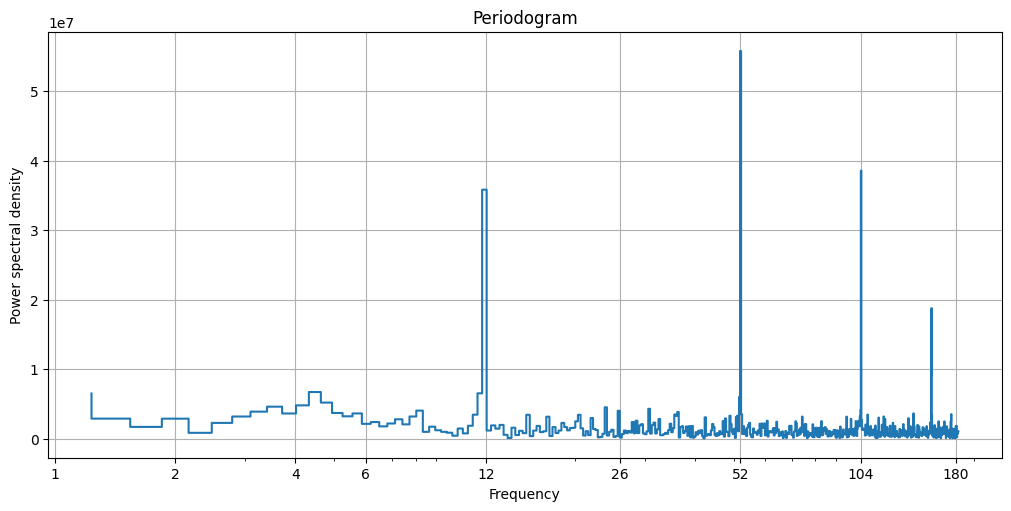

In [75]:
from etna.analysis import plot_periodogram

plot_periodogram(new1_ts, period=365.25, xticks=[1, 2, 4, 6, 12, 26, 52, 104, 180])

### CatBoost model

A shared multi-segment CatBoost model tests whether nonlinear relationships and cross-segment information improve the five-day forecast. Two lag specifications are evaluated: a single weekly lag and a horizon-safe lag window.

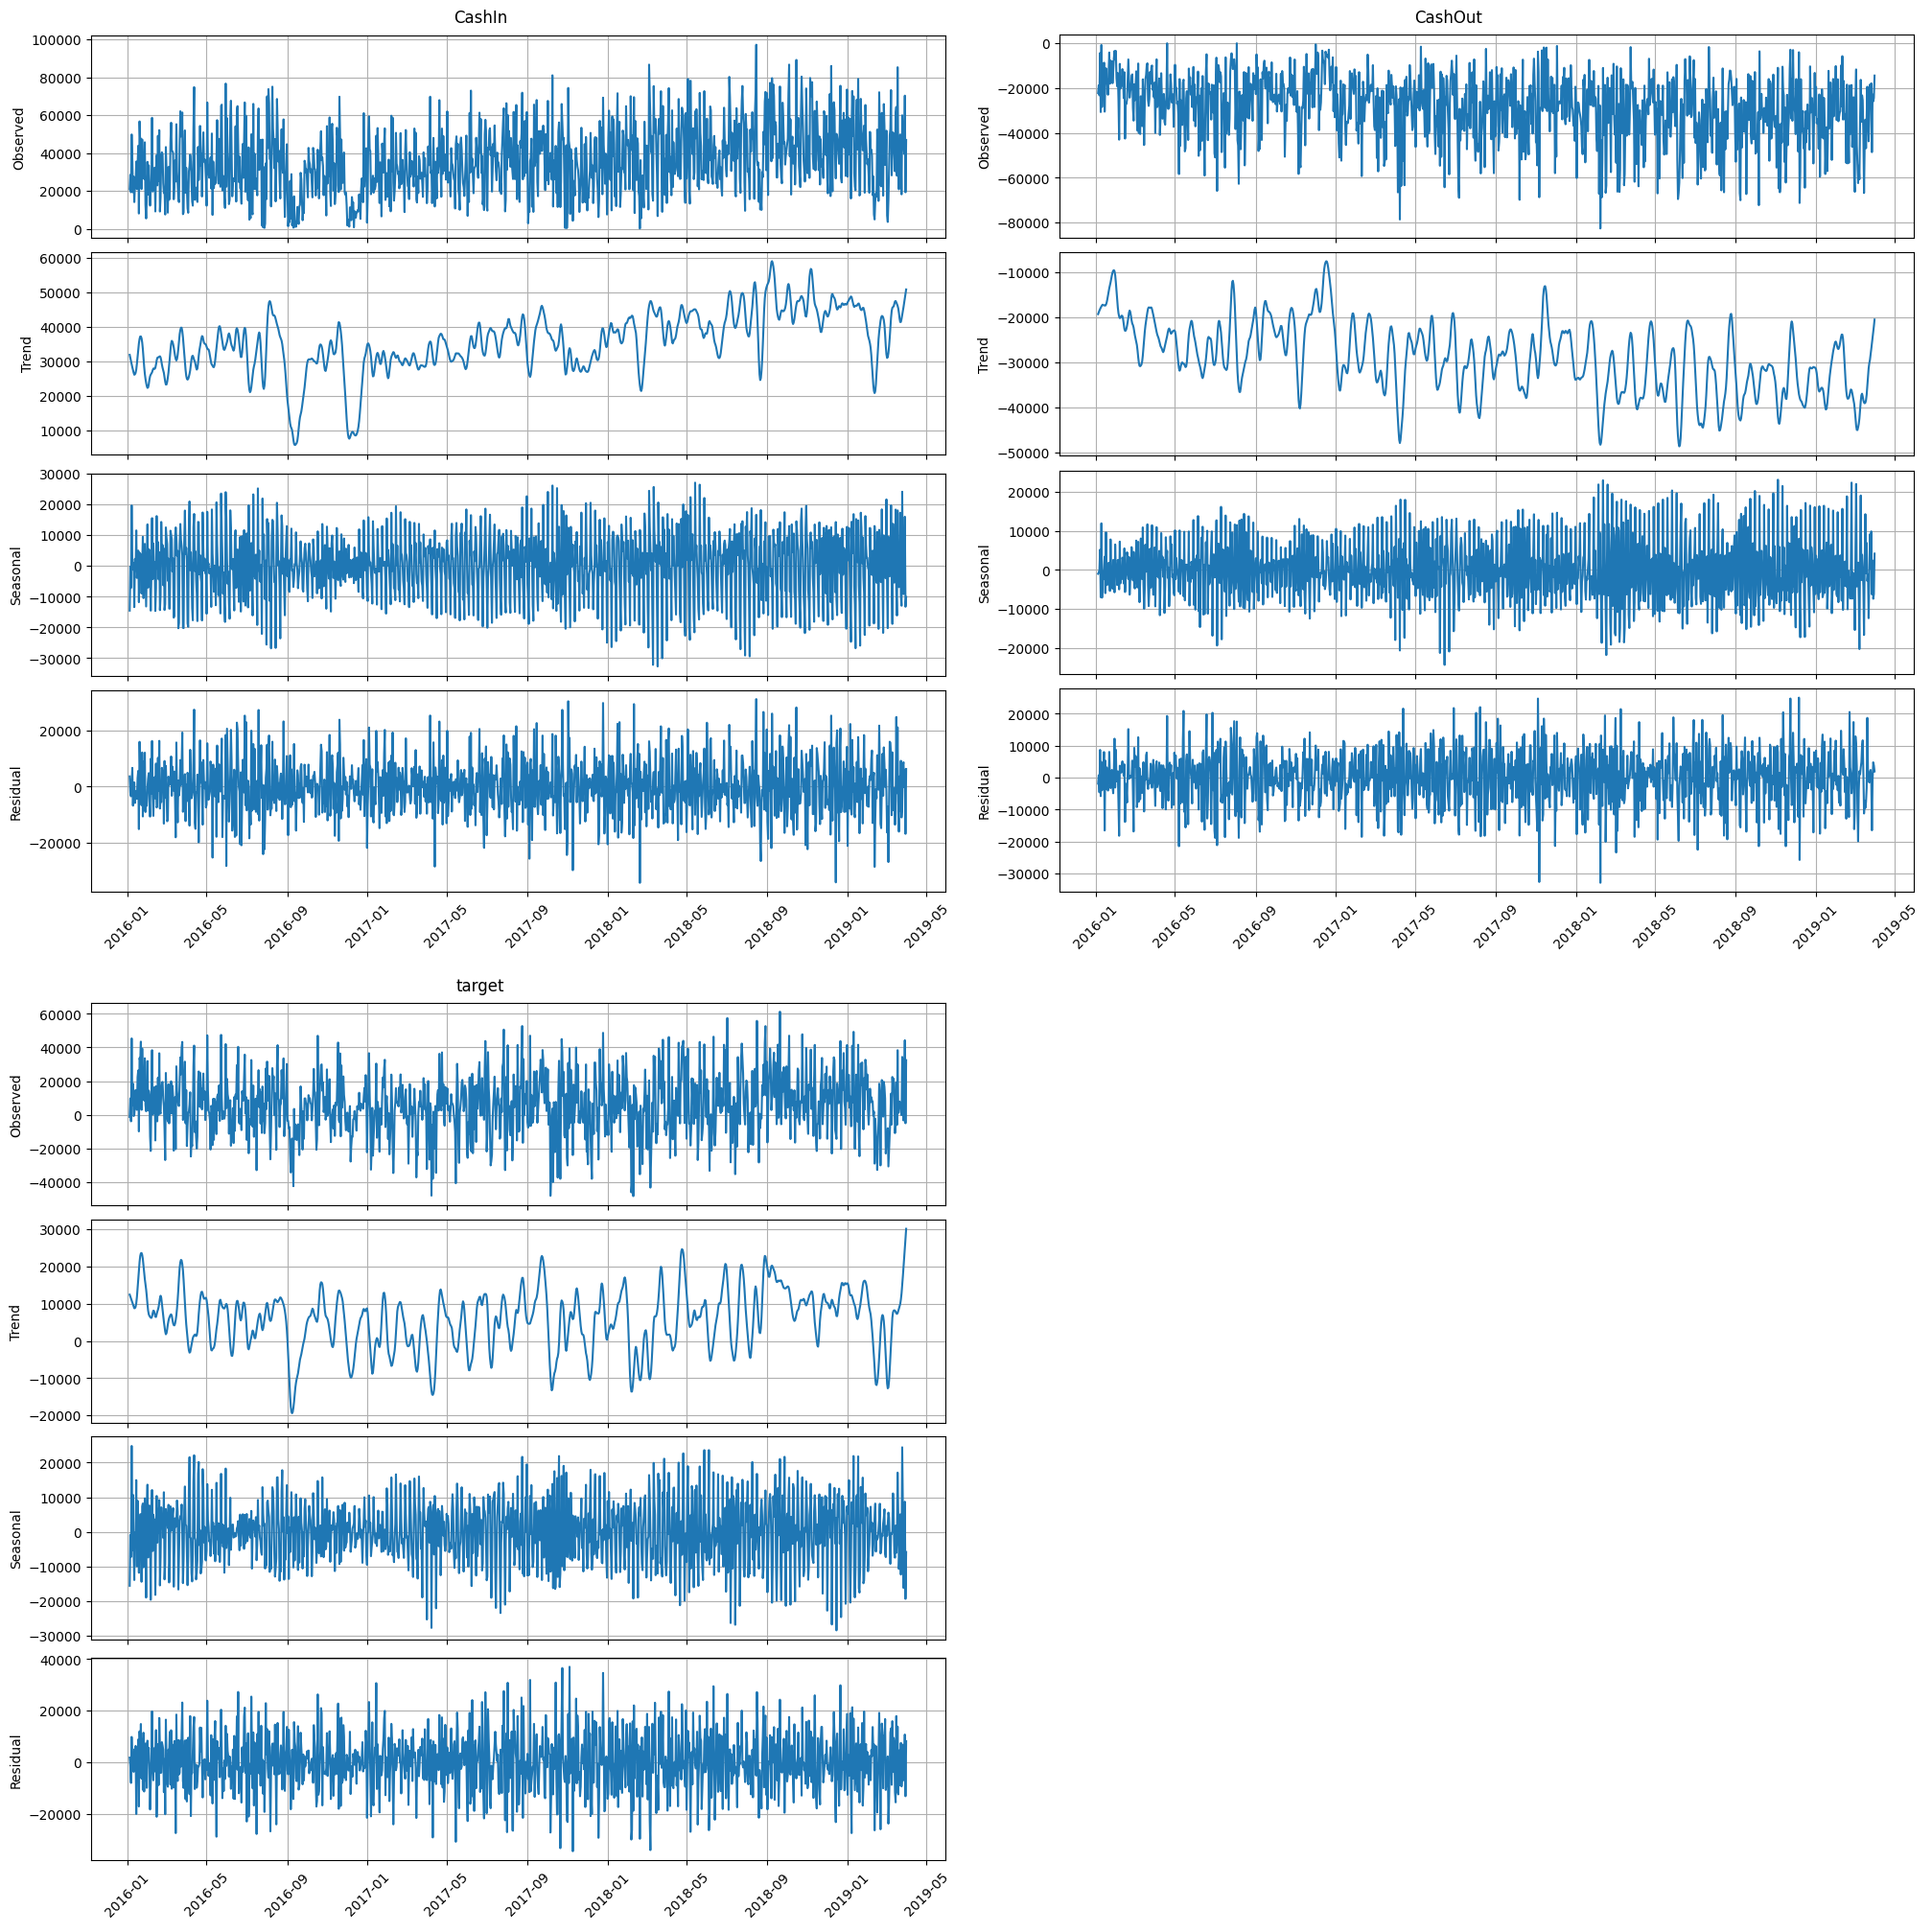

In [76]:
stl_plot(ts=new1_ts, period=7)

The first five-day CatBoost specification combines preprocessing, a linear trend, a seven-day lag, calendar flags, and STL components. It reaches MAE values of **24,388.62** for `CashIn`, **17,385.76** for `CashOut`, and **17,590.80** for net cash flow. The net result is better than the later horizon-safe CatBoost variant, but it does not outperform cleaned Prophet or the recursive linear pipeline.

In [78]:
pipeline = Pipeline(
    transforms=[
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="mean",
        ),
        DensityOutliersTransform(
            in_column="target",
            window_size=30,
            n_neighbors=7,
            distance_coef=1.5,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
        LinearTrendTransform(in_column="target"),
        LagTransform(in_column="target", lags=[7]),
        d_flags,
        # HolidayTransform(iso_code="TUR", out_column="TUR_holidays"),
        STLTransform(
            in_column="target",
            period=3,
            model="arima",
        ),
    ],
    model=CatBoostMultiSegmentModel(),
    horizon=HORIZON,
)

backtest_result = pipeline.backtest(
    ts=ts,
    metrics=[MAE(), SMAPE()],
    n_folds=3,
    aggregate_metrics=True,
)

metrics = backtest_result["metrics"]
forecast = backtest_result["forecasts"]
fold_info = backtest_result["fold_info"]

metrics

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    4.8s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:   10.9s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:   15.6s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   15.6s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    3.2s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    3.2s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s finished


,segment,MAE,SMAPE
0,CashIn,24388.622952,69.480488
1,CashOut,17385.763147,53.545923
2,target,17590.804138,153.638641


## Multi-step forecasting strategies

Forecasting beyond the next observation requires a strategy for producing the complete five-day horizon. Three approaches are compared:

- **Recursive:** predict one step ahead and feed predictions back as lagged inputs.
- **Direct:** predict the full horizon without recursively consuming earlier predictions.
- **Hybrid (DirRec):** combine recursive and direct pipelines across sub-horizons.

Lag construction is adapted to the information available under each strategy.

### Recursive strategy

A linear per-segment model is paired with an autoregressive pipeline and lags from one through seven days. It achieves five-day MAE values of **12,596.49** for `CashIn`, **7,785.50** for `CashOut`, and **13,410.67** for net cash flow. This is the best result for `CashOut` and net cash flow among the comparable five-day experiments, while its `CashIn` error is only marginally above cleaned Prophet.

In [79]:
from etna.pipeline import AutoRegressivePipeline, Pipeline, assemble_pipelines
from etna.ensembles import DirectEnsemble

In [80]:
model = LinearPerSegmentModel()  # Best-performing recursive specification

transforms = [
    TimeSeriesImputerTransform(
        in_column="target",
        strategy="seasonal",
        seasonality=7,
    ),
    TimeSeriesImputerTransform(
        in_column="target",
        strategy="mean",
    ),
    DensityOutliersTransform(
        in_column="target",
        window_size=30,
        n_neighbors=7,
        distance_coef=1.5,
    ),
    TimeSeriesImputerTransform(
        in_column="target",
        strategy="seasonal",
        seasonality=7,
    ),
    LinearTrendTransform(in_column="target"),
    LagTransform(
        in_column="target",
        lags=list(range(1, 8)),
    ),
    d_flags,
    # HolidayTransform(iso_code="TUR", out_column="TUR_holidays"),
    # STLTransform(in_column="target", period=3, model="arima"),
]

autoregressive_pipeline = AutoRegressivePipeline(
    model=model,
    transforms=transforms,
    horizon=5,
    step=1,
)

recursive_backtest_result = autoregressive_pipeline.backtest(
    ts=ts,
    metrics=[MAE(), SMAPE()],
    n_folds=3,
    aggregate_metrics=True,
)

metrics_recursive_df = recursive_backtest_result["metrics"]
forecast_recursive = recursive_backtest_result["forecasts"]
fold_info_recursive = recursive_backtest_result["fold_info"]
fitted_pipelines_recursive = recursive_backtest_result["pipelines"]

metrics_recursive_df

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.9s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    1.9s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    3.9s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    6.7s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    6.7s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.1s finished


,segment,MAE,SMAPE
0,CashIn,12596.492738,30.857292
1,CashOut,7785.504276,26.579704
2,target,13410.665299,118.243791


### Direct strategy

The direct CatBoost pipeline uses horizon-safe lag features and STL decomposition. Its MAE values—**23,800.59**, **18,161.20**, and **18,377.89**—are higher than those of the recursive linear pipeline for every segment, so the added nonlinear complexity does not improve this five-day task.

In [83]:
pipeline = Pipeline(
    transforms=[
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="mean",
        ),
        DensityOutliersTransform(
            in_column="target",
            window_size=30,
            n_neighbors=7,
            distance_coef=1.5,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
        LinearTrendTransform(in_column="target"),
        LagTransform(
            in_column="target",
            lags=list(range(5, 5 + 7)),
        ),
        d_flags,
        # HolidayTransform(iso_code="TUR", out_column="TUR_holidays"),
        STLTransform(
            in_column="target",
            period=3,
            model="arima",
        ),
    ],
    model=CatBoostMultiSegmentModel(),
    horizon=HORIZON,
)

backtest_result = pipeline.backtest(
    ts=ts,
    metrics=[MAE(), SMAPE()],
    n_folds=3,
    aggregate_metrics=True,
)

metrics = backtest_result["metrics"]
forecast = backtest_result["forecasts"]
fold_info = backtest_result["fold_info"]
fitted_pipelines = backtest_result["pipelines"]

metrics

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    8.1s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:   15.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:   22.7s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   22.7s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    3.3s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    3.3s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


,segment,MAE,SMAPE
0,CashIn,23800.592942,65.952938
1,CashOut,18161.204889,55.700023
2,target,18377.893181,157.553406


### Hybrid strategy

The hybrid experiment combines an autoregressive linear pipeline for the first three forecast steps with a direct CatBoost pipeline through day five. It improves substantially on the standalone horizon-safe CatBoost model, reaching MAE values of **17,496.24**, **11,290.25**, and **14,800.87**, but remains less accurate than the recursive linear pipeline across all three segments.

In [84]:
horizons = [3, 5]

recursive_transforms = [
    TimeSeriesImputerTransform(
        in_column="target",
        strategy="seasonal",
        seasonality=7,
    ),
    TimeSeriesImputerTransform(
        in_column="target",
        strategy="mean",
    ),
    DensityOutliersTransform(
        in_column="target",
        window_size=30,
        n_neighbors=7,
        distance_coef=1.5,
    ),
    TimeSeriesImputerTransform(
        in_column="target",
        strategy="seasonal",
        seasonality=7,
    ),
    LinearTrendTransform(in_column="target"),
    LagTransform(
        in_column="target",
        lags=list(range(1, 8)),
    ),
    d_flags,
    # HolidayTransform(iso_code="TUR", out_column="TUR_holidays"),
    # STLTransform(in_column="target", period=horizons[0], model="arima"),
]

pipeline_1 = AutoRegressivePipeline(
    model=LinearPerSegmentModel(),
    transforms=recursive_transforms,
    horizon=horizons[0],
    step=1,
)

direct_transforms = [
    TimeSeriesImputerTransform(
        in_column="target",
        strategy="seasonal",
        seasonality=7,
    ),
    TimeSeriesImputerTransform(
        in_column="target",
        strategy="mean",
    ),
    DensityOutliersTransform(
        in_column="target",
        window_size=30,
        n_neighbors=7,
        distance_coef=1.5,
    ),
    TimeSeriesImputerTransform(
        in_column="target",
        strategy="seasonal",
        seasonality=7,
    ),
    LinearTrendTransform(in_column="target"),
    LagTransform(
        in_column="target",
        lags=list(range(horizons[1], horizons[1] + 7)),
    ),
    d_flags,
    # HolidayTransform(iso_code="TUR", out_column="TUR_holidays"),
    STLTransform(
        in_column="target",
        period=3,
        model="arima",
    ),
]

pipeline_2 = Pipeline(
    model=CatBoostMultiSegmentModel(),
    transforms=direct_transforms,
    horizon=horizons[1],
)

ensemble = DirectEnsemble(
    pipelines=[pipeline_1, pipeline_2],
)

ensemble_backtest_result = ensemble.backtest(
    ts=ts,
    metrics=[MAE(), SMAPE()],
    n_folds=3,
    aggregate_metrics=True,
)

metrics_ensemble_df = ensemble_backtest_result["metrics"]
forecast_ensemble = ensemble_backtest_result["forecasts"]
fold_info_ensemble = ensemble_backtest_result["fold_info"]
fitted_pipelines_ensemble = ensemble_backtest_result["pipelines"]

metrics_ensemble_df

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    7.4s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    7.4s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    7.4s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    8.2s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    8.2s finished
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:   15.6s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    7.1s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    7.1s finished
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:   22.7s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   22.7s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    1.5s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    3.2s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elaps

,segment,MAE,SMAPE
0,CashIn,17496.239128,43.290652
1,CashOut,11290.248296,33.979461
2,target,14800.872217,133.060219


### Strategy selection

The updated five-day backtests favor the recursive linear strategy overall. Cleaned Prophet has the lowest `CashIn` MAE by a very small margin (**12,573.04** versus **12,596.49**), while recursive linear forecasting is clearly strongest for `CashOut` (**7,785.50**) and net cash flow (**13,410.67**). Neither the direct CatBoost nor the hybrid construction improves on those segment-level leaders.

## Ensemble forecasting

A weighted voting ensemble combines the autoregressive linear pipeline with the direct CatBoost pipeline using an 8:1 weighting. The result is much stronger than standalone direct CatBoost and remains competitive for withdrawals and net cash flow. However, it does not surpass recursive linear forecasting on any segment, indicating that the weaker CatBoost component adds diversity but no incremental accuracy in this experiment.

In [85]:
from etna.ensembles import StackingEnsemble, VotingEnsemble

In [86]:
HORIZON = 5
N_FOLDS = 3

linear_pipeline = AutoRegressivePipeline(
    model=LinearPerSegmentModel(),
    transforms=[
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="mean",
        ),
        DensityOutliersTransform(
            in_column="target",
            window_size=30,
            n_neighbors=7,
            distance_coef=1.5,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
        LinearTrendTransform(in_column="target"),
        LagTransform(
            in_column="target",
            lags=list(range(1, 8)),
        ),
        d_flags,
        # HolidayTransform(iso_code="TUR", out_column="TUR_holidays"),
        # STLTransform(in_column="target", period=3, model="arima"),
    ],
    horizon=HORIZON,
    step=1,
)

catboost_pipeline = Pipeline(
    model=CatBoostMultiSegmentModel(),
    transforms=[
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="mean",
        ),
        DensityOutliersTransform(
            in_column="target",
            window_size=30,
            n_neighbors=7,
            distance_coef=1.5,
        ),
        TimeSeriesImputerTransform(
            in_column="target",
            strategy="seasonal",
            seasonality=7,
        ),
        LinearTrendTransform(in_column="target"),
        LagTransform(
            in_column="target",
            lags=list(range(HORIZON, HORIZON + 7)),
        ),
        d_flags,
        # HolidayTransform(iso_code="TUR", out_column="TUR_holidays"),
        STLTransform(
            in_column="target",
            period=3,
            model="arima",
        ),
    ],
    horizon=HORIZON,
)

pipeline_names = ["linear", "catboost"]
pipelines = [linear_pipeline, catboost_pipeline]

In [88]:
voting_ensemble = VotingEnsemble(
    pipelines=pipelines,
    weights=[8, 1],
)

voting_backtest_result = voting_ensemble.backtest(
    ts=ts,
    metrics=[MAE(), SMAPE()],
    n_folds=N_FOLDS,
    aggregate_metrics=True,
)

voting_ensemble_metrics = voting_backtest_result["metrics"]
voting_ensemble_forecasts = voting_backtest_result["forecasts"]
voting_ensemble_fold_info = voting_backtest_result["fold_info"]
voting_ensemble_pipelines = voting_backtest_result["pipelines"]

# Keep segment names while displaying them as the index
voting_ensemble_metrics = voting_ensemble_metrics.set_index("segment")

voting_ensemble_metrics

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    7.3s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    7.3s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    7.3s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    8.5s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    8.5s finished
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:   15.8s
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    7.5s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    7.5s finished
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:   23.3s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:   23.3s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    3.1s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    4.2s
[Parallel(n_jobs=1)]: Done   2 out of   2 | elaps

,MAE,SMAPE
segment,,
CashIn,13621.988955,33.342595
CashOut,7937.764926,27.045365
target,13614.255454,121.625818


## Conclusions

This project builds an end-to-end ATM cash forecasting workflow spanning exploratory analysis, ETNA dataset design, robust preprocessing, hierarchical reconciliation, feature engineering, multi-step forecasting, and ensembles.

### Five-day backtest summary

The table reports MAE averaged across three folds. The exploratory one-step linear result is excluded because it is not directly comparable with the five-day evaluations.

| Model | `CashIn` MAE | `CashOut` MAE | Net-flow MAE |
|---|---:|---:|---:|
| Prophet | 13,647.48 | 12,842.02 | 14,257.11 |
| Prophet with preprocessing | **12,573.04** | 11,374.01 | 13,964.72 |
| CatBoost, weekly lag | 24,388.62 | 17,385.76 | 17,590.80 |
| Recursive linear | 12,596.49 | **7,785.50** | **13,410.67** |
| Direct CatBoost | 23,800.59 | 18,161.20 | 18,377.89 |
| Hybrid direct-recursive | 17,496.24 | 11,290.25 | 14,800.87 |
| Weighted voting ensemble | 13,621.99 | 7,937.76 | 13,614.26 |

Bottom-up hierarchical Prophet produces a coherent total forecast with MAE **14,273.47**. This is slightly less accurate than forecasting net flow directly with preprocessed Prophet, showing that reconciliation contributes accounting consistency rather than an automatic accuracy gain.

### Main findings

- Seasonal imputation followed by density-based anomaly treatment reduces Prophet MAE for every segment: by **7.9%** for `CashIn`, **11.4%** for `CashOut`, and **2.1%** for net cash flow.
- Recursive linear forecasting is the strongest overall five-day strategy. It delivers the lowest MAE for withdrawals and net cash flow and nearly ties cleaned Prophet for deposits.
- Direct CatBoost underperforms the simpler recursive model. The hybrid and voting constructions recover much of that gap, but neither improves on recursive linear forecasting.
- Net-flow SMAPE remains above 118% for the strongest candidates because the signed target crosses zero. MAE is therefore the more reliable operational selection criterion.

For deployment, the evidence supports preprocessed Prophet for deposit forecasts and recursive linear forecasting for withdrawals and net cash flow. If strict accounting coherence is required, the component forecasts should be reconciled before replenishment decisions are generated. Performance should be monitored separately by segment and forecast horizon because the three cash-flow series exhibit materially different error profiles.